# 02 — Coordinate System Analysis

**Project:** Discovering New EuroLeague Player Roles Using Unsupervised Learning

**Task:** a focused, evidence-driven investigation of what `coord_x` and `coord_y` in
`data/raw/euroleague_points.csv` actually represent — their likely units, orientation, basket
location, stability across seasons/games/teams, and relationship to the `zone` column — so
that a future Feature Engineering task can decide, with documented evidence, which
coordinate-derived features are safe to build.

## Explicit scope boundary

This notebook is a coordinate-system investigation only. It deliberately does **not**:

- Build the final player-season-team modeling table
- Create the full model feature set, or any per-36 statistics
- Fit `StandardScaler`, PCA, K-Means, or a Gaussian Mixture Model
- Select a number of clusters or name player roles
- Drop observations from the future modeling sample, or impute missing values
- Modify `data/raw/*.csv`, `data/processed/merged_euroleague_players.csv`,
  `notebooks/EuroLeague_Unsupervised_Roles.ipynb`, or `notebooks/01_data_audit.ipynb`

Coordinate-derived columns (e.g. a provisional distance-from-basket) are calculated only
*temporarily*, inside this notebook, to test hypotheses. None are exported as final model
features — Section 18 only *proposes* candidate features for a later, separately approved
task.

## Notebook narrative convention (see `CLAUDE.md`)

Every analytical step below follows a fixed evidence chain:

**Objective → Implementation → Finding → Interpretation → Decision → (Remaining Uncertainty) → next Objective**

A Markdown cell states the question and why it matters *before* the code that answers it.
The code produces a table, statistic, or chart. The Markdown cell immediately after states
what was actually found, what it means, and what decision follows — or explicitly says the
evidence is insufficient. Conclusions are never written before the corresponding output
exists.

## Reproducibility

- Repository root is resolved at runtime (see Setup below); all paths are
  repository-relative via `pathlib.Path`.
- `RANDOM_STATE = 42` is used for every deterministic sample (e.g. scatter-plot subsampling).
- Numerical summaries (percentiles, counts) always use the full dataset, never a sample.

## Setup: Repository Root, Imports, and Helper Functions

Reuses the same repository-root resolution approach as `notebooks/01_data_audit.ipynb`, plus
a small set of helpers specific to this task: saving figures/tables into the
`outputs/*/coordinates/` subdirectories, an equal-aspect scatter/hexbin helper (so spatial
geometry is not visually distorted), and a helper to evaluate a candidate basket location
against the observed 2PT/3PT boundary.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


def find_repo_root(start: Path, markers=("data", "notebooks")) -> Path:
    """Walk upward from `start` until a directory containing all `markers` is found."""
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate repository root from {start}. Expected: {markers}")


_start = Path(globals().get("__file__", Path.cwd()))
REPO_ROOT = find_repo_root(_start)
print(f"Resolved repository root: {REPO_ROOT}")

DATA_RAW = REPO_ROOT / "data" / "raw"
POINTS_PATH = DATA_RAW / "euroleague_points.csv"

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "coordinates"
TABLE_DIR = REPO_ROOT / "outputs" / "tables" / "coordinates"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

assert POINTS_PATH.exists(), f"Required data file is missing: {POINTS_PATH}"
print("euroleague_points.csv located.")

Resolved repository root: C:\Users\doron\PycharmProjects\euroleague-player-roles
euroleague_points.csv located.


In [2]:
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def save_table(df: pd.DataFrame, filename: str) -> Path:
    """Save a table to outputs/tables/coordinates/ and return its path."""
    out_path = TABLE_DIR / filename
    df.to_csv(out_path, index=False)
    print(f"Saved table: {out_path.relative_to(REPO_ROOT)}  (rows={len(df)})")
    return out_path


def save_figure(fig, filename: str) -> Path:
    """Save a figure to outputs/figures/coordinates/ and return its path."""
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {out_path.relative_to(REPO_ROOT)}")
    return out_path


def coord_percentile_table(series: pd.Series, name: str) -> dict:
    """Full descriptive-statistics record for one coordinate column, incl. 0.1/99.9 pct."""
    pcts = series.describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .999])
    return {
        "column": name,
        "count": int(series.count()),
        "missing_count": int(series.isna().sum()),
        "missing_percentage": round(100 * series.isna().mean(), 4),
        "min": pcts["min"], "max": pcts["max"],
        "mean": round(series.mean(), 3), "median": series.median(), "std": round(series.std(), 3),
        "p0.1": pcts["0.1%"], "p1": pcts["1%"], "p5": pcts["5%"], "p25": pcts["25%"],
        "p50": pcts["50%"], "p75": pcts["75%"], "p95": pcts["95%"], "p99": pcts["99%"],
        "p99.9": pcts["99.9%"],
    }


def equal_aspect_scatter(ax, x, y, **kwargs):
    """Scatter with equal aspect ratio so spatial geometry (court shape) is not distorted."""
    ax.scatter(x, y, **kwargs)
    ax.set_aspect("equal", adjustable="box")
    return ax


def equal_aspect_hexbin(ax, x, y, **kwargs):
    """Hexbin density plot with equal aspect ratio."""
    hb = ax.hexbin(x, y, **kwargs)
    ax.set_aspect("equal", adjustable="box")
    return hb


def evaluate_basket_candidate(shots_df, cx, cy, two_ids, three_ids, cut_range=range(500, 800, 5)):
    """Score a candidate basket location (cx, cy) by how cleanly it separates 2PT vs 3PT
    attempts on Euclidean distance. Returns a summary dict; does not mutate shots_df.
    """
    dist = np.sqrt((shots_df["coord_x"] - cx) ** 2 + (shots_df["coord_y"] - cy) ** 2)
    two_d = dist[shots_df["action_id"].isin(two_ids)]
    three_d = dist[shots_df["action_id"].isin(three_ids)]

    best_cut, best_err = None, np.inf
    for cut in cut_range:
        err = (two_d > cut).mean() + (three_d < cut).mean()
        if err < best_err:
            best_err, best_cut = err, cut

    return {
        "candidate_x": cx, "candidate_y": cy,
        "median_dist_2pt": round(float(two_d.median()), 2),
        "median_dist_3pt": round(float(three_d.median()), 2),
        "pct_3pt_farther_than_2pt_median": round(100 * float((three_d > two_d.median()).mean()), 3),
        "best_separation_cut": best_cut,
        "pct_2pt_over_cut": round(100 * float((two_d > best_cut).mean()), 4),
        "pct_3pt_under_cut": round(100 * float((three_d < best_cut).mean()), 4),
        "total_misclassification_pct": round(100 * float(best_err), 4),
    }


print("Helper functions defined: save_table, save_figure, coord_percentile_table, "
      "equal_aspect_scatter, equal_aspect_hexbin, evaluate_basket_candidate")

Helper functions defined: save_table, save_figure, coord_percentile_table, equal_aspect_scatter, equal_aspect_hexbin, evaluate_basket_candidate


## Section 1 — Initial Data Selection

### Objective

Load `euroleague_points.csv` and understand which rows represent genuine shot (field-goal)
attempts before doing any coordinate analysis. Coordinates on non-shot events (e.g. free
throws, which always happen from the same fixed spot) would corrupt any spatial analysis if
included, so the inclusion rule must be established and justified from the data itself —
not assumed from column names.

In [3]:
points_df = pd.read_csv(POINTS_PATH, low_memory=False)
print(f"Rows: {len(points_df):,} | Columns: {points_df.shape[1]}")
print(f"Seasons: {points_df['season_code'].nunique()} | Games: {points_df['game_id'].nunique()} | "
      f"Players: {points_df['player_id'].nunique()}")
print()
relevant_cols = ["game_point_id", "game_id", "season_code", "team_id", "player_id",
                  "action_id", "action", "points", "coord_x", "coord_y", "zone"]
display(points_df[relevant_cols].dtypes.to_frame("dtype"))
print()
for col in ["coord_x", "coord_y", "zone"]:
    n_missing = int(points_df[col].isna().sum())
    print(f"{col}: missing = {n_missing} ({100 * n_missing / len(points_df):.4f}%)")

Rows: 755,145 | Columns: 24
Seasons: 19 | Games: 5039 | Players: 2092



,dtype
game_point_id,str
game_id,str
season_code,str
team_id,str
player_id,str
action_id,str
action,str
points,int64
coord_x,int64
coord_y,int64



coord_x: missing = 0 (0.0000%)
coord_y: missing = 0 (0.0000%)
zone: missing = 141019 (18.6744%)


In [4]:
# action_id / action mapping -- this is the evidence base for the inclusion rule below.
action_map = pd.crosstab(points_df["action_id"], points_df["action"])
display(action_map)

action_points = points_df.groupby("action_id")["points"].agg(["min", "max", "mean", "count"])
display(action_points)

action,Dunk,Free Throw In,Layup Made,Missed Layup,Missed Three Pointer,Missed Two Pointer,Three Pointer,Two Pointer
action_id,,,,,,,,
2FGA,0,0,0,0,0,147240,0,0
2FGAB,0,0,0,0,0,5897,0,0
2FGM,0,0,0,0,0,0,0,160519
3FGA,0,0,0,0,148262,0,0,0
3FGAB,0,0,0,0,687,0,0,0
3FGM,0,0,0,0,0,0,84421,0
DUNK,7079,0,0,0,0,0,0,0
FTM,0,140926,0,0,0,0,0,0
LAYUPATT,0,0,0,26029,0,0,0,0


,min,max,mean,count
action_id,,,,
2FGA,0,0,0.0,147240
2FGAB,0,0,0.0,5897
2FGM,2,2,2.0,160519
3FGA,0,0,0.0,148262
3FGAB,0,0,0.0,687
3FGM,3,3,3.0,84421
DUNK,2,2,2.0,7079
FTM,1,1,1.0,140926
LAYUPATT,0,0,0.0,26029


### Finding

The crosstab shows a one-to-one mapping between `action_id` and `action` description (each
`action_id` maps to exactly one `action` text, confirming the Data Audit's Section 6.2
finding). Ten `action_id` values exist overall: `2FGA`, `2FGAB`, `2FGM` (2-point miss /
missed-and-blocked / make), `3FGA`, `3FGAB`, `3FGM` (3-point equivalents), `DUNK`,
`LAYUPATT`, `LAYUPMD` (dunk/layup miss-make, always worth 2), and `FTM` (free throw made).
`points` is 0 for every miss code, 1 for `FTM`, 2 for two-point/dunk/layup makes, 3 for
`3FGM` — consistent with each code's basketball meaning.

### Interpretation

Every code except `FTM` corresponds to an attempt at a field goal from a variable court
location. `FTM` is a free throw: by rule, every free throw in a game is shot from the same
fixed spot on the floor, so its "coordinate", if present, cannot reflect shot placement the
way a field-goal attempt's coordinate does.

### Decision

Define the shot-attempt subset as every row whose `action_id` is one of:
`2FGA, 2FGAB, 2FGM, 3FGA, 3FGAB, 3FGM, DUNK, LAYUPATT, LAYUPMD` — i.e. every field-goal
attempt code — and explicitly exclude `FTM`. This is verified below by checking whether the
two groups partition the full file with no leftover rows, and independently by inspecting
`FTM`'s actual recorded coordinates.

In [5]:
SHOT_ACTION_IDS = ["2FGA", "2FGAB", "2FGM", "3FGA", "3FGAB", "3FGM", "DUNK", "LAYUPATT", "LAYUPMD"]
TWO_PT_IDS = ["2FGA", "2FGAB", "2FGM", "DUNK", "LAYUPATT", "LAYUPMD"]
THREE_PT_IDS = ["3FGA", "3FGAB", "3FGM"]
MADE_IDS = ["2FGM", "3FGM", "DUNK", "LAYUPMD"]
MISSED_IDS = ["2FGA", "2FGAB", "3FGA", "3FGAB", "LAYUPATT"]

shots = points_df[points_df["action_id"].isin(SHOT_ACTION_IDS)].copy()
ft = points_df[points_df["action_id"] == "FTM"]

partition_complete = len(shots) + len(ft) == len(points_df)
print(f"Total rows: {len(points_df):,}")
print(f"Shot-attempt rows: {len(shots):,}")
print(f"FTM (free throw) rows: {len(ft):,}")
print(f"Shot-attempt + FTM == total rows: {partition_complete}")
print()
print(f"Made shots: {int(shots['action_id'].isin(MADE_IDS).sum()):,}")
print(f"Missed shots: {int(shots['action_id'].isin(MISSED_IDS).sum()):,}")
print(f"Two-point attempts: {int(shots['action_id'].isin(TWO_PT_IDS).sum()):,}")
print(f"Three-point attempts: {int(shots['action_id'].isin(THREE_PT_IDS).sum()):,}")
print()
n_usable = int(shots[["coord_x", "coord_y"]].notna().all(axis=1).sum())
print(f"Shot-attempt rows with usable (non-missing) coordinates: {n_usable:,} "
      f"({100 * n_usable / len(shots):.4f}%)")
print(f"Shot-attempt rows with missing coordinates: {len(shots) - n_usable:,}")

Total rows: 755,145
Shot-attempt rows: 614,219
FTM (free throw) rows: 140,926
Shot-attempt + FTM == total rows: True

Made shots: 286,104
Missed shots: 328,115
Two-point attempts: 380,849
Three-point attempts: 233,370

Shot-attempt rows with usable (non-missing) coordinates: 614,219 (100.0000%)
Shot-attempt rows with missing coordinates: 0


In [6]:
# Check FTM's own recorded coordinates -- confirms whether excluding it was the right call.
print("FTM coord_x / coord_y summary (should NOT vary if it is a fixed-spot event):")
display(ft[["coord_x", "coord_y"]].describe())
print()
print("Distinct (coord_x, coord_y) pairs recorded for FTM:")
display(ft[["coord_x", "coord_y"]].drop_duplicates())

FTM coord_x / coord_y summary (should NOT vary if it is a fixed-spot event):


,coord_x,coord_y
count,140926.0,140926.0
mean,-1.0,-1.0
std,0.0,0.0
min,-1.0,-1.0
25%,-1.0,-1.0
50%,-1.0,-1.0
75%,-1.0,-1.0
max,-1.0,-1.0



Distinct (coord_x, coord_y) pairs recorded for FTM:


,coord_x,coord_y
33,-1,-1


### Finding

The partition is exact: shot-attempt rows + `FTM` rows equal the total row count, so no
event type was missed or double-counted. `FTM`'s coordinate is a **single constant pair,
`(-1, -1)`, for all 140,926 free-throw rows** — zero variance. Shot-attempt rows have 0%
missing coordinates.

### Interpretation

`FTM`'s coordinate is not a measured location at all — it is a fixed sentinel value written
for every free throw regardless of which basket or which arena, which is exactly what would
be expected if the source system only records a real `(x, y)` for shots whose location
varies. This independently confirms the free-throw exclusion decision above, and it also
flags `(-1, -1)` as a possible "no real location" convention elsewhere in the file — a
question picked up later in Section 8 (Quantization).

### Decision

Proceed with `shots` (the 9-action-id subset) as the working DataFrame for the rest of this
notebook. All coordinate analysis below uses `shots`, not `points_df`, unless stated
otherwise. `FTM` rows are excluded from every spatial computation.

## Section 2 — Global Coordinate Distribution

### Objective

Characterize the overall shape of `coord_x` and `coord_y` on shot-attempt rows: range,
central tendency, spread, and percentiles (including extreme 0.1st/99.9th), plus a visual
read on whether the point cloud resembles a basketball court, and whether it looks like one
half-court or two mirrored halves. This is the foundation every later hypothesis builds on.

In [7]:
coord_stats = pd.DataFrame([
    coord_percentile_table(shots["coord_x"], "coord_x"),
    coord_percentile_table(shots["coord_y"], "coord_y"),
])
display(coord_stats)
save_table(coord_stats, "coordinate_summary.csv")

,column,count,missing_count,missing_percentage,min,max,mean,median,std,p0.1,p1,p5,p25,p50,p75,p95,p99,p99.9
0,coord_x,614219,0,0.0,-740.0,746.0,-0.987,0.0,332.788,-715.0,-690.0,-602.0,-169.0,0.0,163.0,602.0,690.0,715.0
1,coord_y,614219,0,0.0,-156.0,1304.0,283.510,181.0,254.981,-75.0,-37.0,6.0,69.0,181.0,508.0,727.0,821.0,1229.0


Saved table: outputs\tables\coordinates\coordinate_summary.csv  (rows=2)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/coordinate_summary.csv')

Saved figure: outputs\figures\coordinates\coord_histograms.png


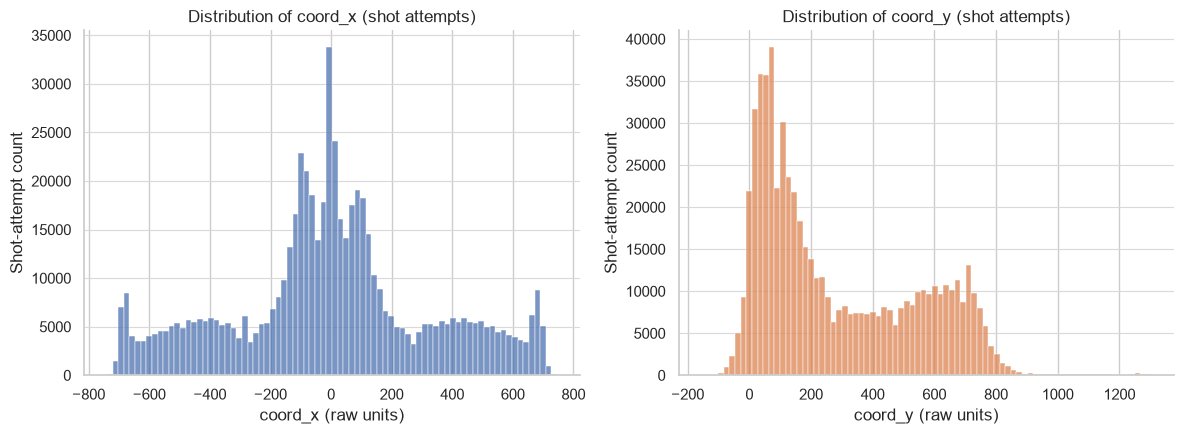

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(shots["coord_x"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of coord_x (shot attempts)")
axes[0].set_xlabel("coord_x (raw units)")
axes[0].set_ylabel("Shot-attempt count")
sns.histplot(shots["coord_y"], bins=80, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of coord_y (shot attempts)")
axes[1].set_xlabel("coord_y (raw units)")
axes[1].set_ylabel("Shot-attempt count")
for ax in axes:
    ax.grid(axis="y", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "coord_histograms.png")
plt.show()

Saved figure: outputs\figures\coordinates\coord_boxplots.png


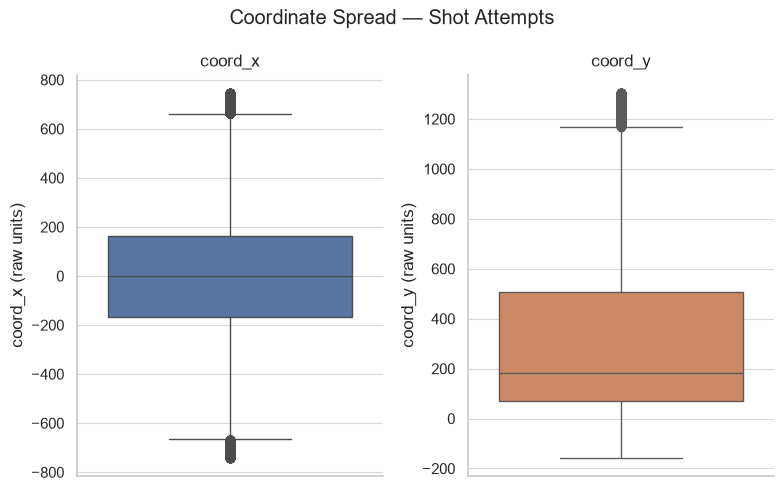

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.boxplot(y=shots["coord_x"], ax=axes[0], color="#4C72B0")
axes[0].set_title("coord_x")
axes[0].set_ylabel("coord_x (raw units)")
sns.boxplot(y=shots["coord_y"], ax=axes[1], color="#DD8452")
axes[1].set_title("coord_y")
axes[1].set_ylabel("coord_y (raw units)")
for ax in axes:
    ax.grid(axis="y", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
fig.suptitle("Coordinate Spread — Shot Attempts")
fig.tight_layout()
save_figure(fig, "coord_boxplots.png")
plt.show()

Saved figure: outputs\figures\coordinates\coord_scatter_sample.png


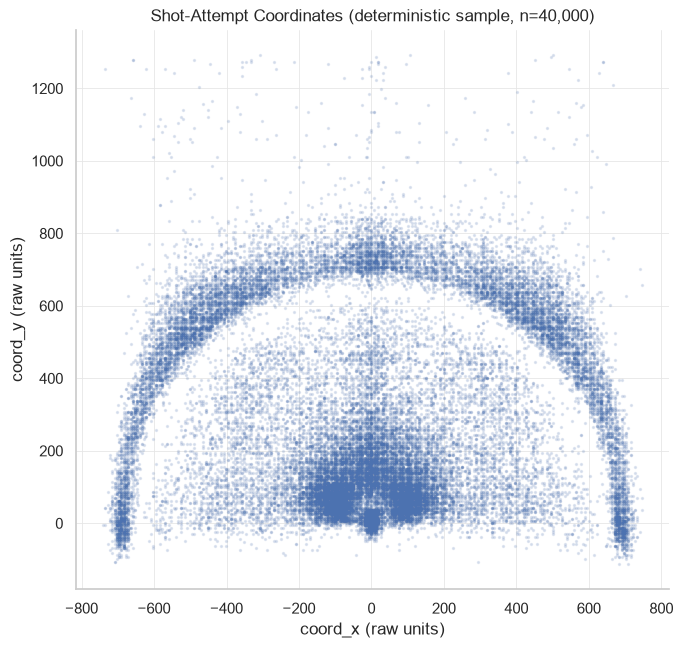

In [10]:
# Scatter uses a deterministic sample (plotting 614K points is inefficient and unreadable);
# numerical summaries above already used the full dataset.
sample = shots.sample(min(40_000, len(shots)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 8))
equal_aspect_scatter(ax, sample["coord_x"], sample["coord_y"], s=2, alpha=0.15, color="#4C72B0")
ax.set_title(f"Shot-Attempt Coordinates (deterministic sample, n={len(sample):,})")
ax.set_xlabel("coord_x (raw units)")
ax.set_ylabel("coord_y (raw units)")
ax.grid(color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "coord_scatter_sample.png")
plt.show()

Saved figure: outputs\figures\coordinates\coord_hexbin_full.png


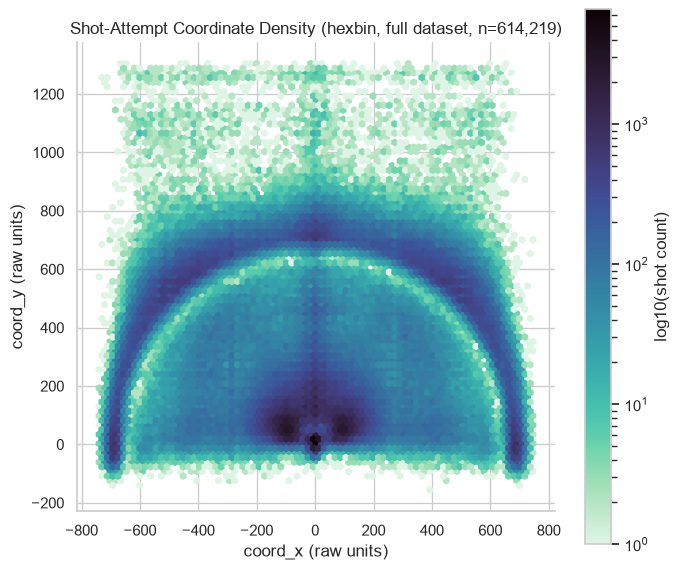

In [11]:
fig, ax = plt.subplots(figsize=(7, 8))
hb = equal_aspect_hexbin(ax, shots["coord_x"], shots["coord_y"], gridsize=80,
                          cmap="mako_r", mincnt=1, bins="log")
ax.set_title(f"Shot-Attempt Coordinate Density (hexbin, full dataset, n={len(shots):,})")
ax.set_xlabel("coord_x (raw units)")
ax.set_ylabel("coord_y (raw units)")
cbar = fig.colorbar(hb, ax=ax, shrink=0.7)
cbar.set_label("log10(shot count)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "coord_hexbin_full.png")
plt.show()

### Finding

`coord_x` ranges roughly from -740 to +746, with mean/median close to 0 (see
`coordinate_summary.csv`) — visually and numerically close to symmetric around zero.
`coord_y` ranges from about -156 to +1304: strongly right-skewed, with most mass concentrated
at low, near-zero-to-slightly-positive values and a long tail extending to over 1300. The
hexbin plot shows a dense, roughly fan/arc-shaped concentration near the bottom of the plot
(low `coord_y`), thinning out with an arc-like edge farther up, and a sparse long tail beyond
that — a single dense region, not two separated dense regions at opposite ends of the y-axis.

### Interpretation

- `coord_x`'s near-zero-centered, roughly symmetric range is consistent with a **lateral
  (left-right) offset from a central reference line** — e.g. the vertical centerline through
  a basket.
- `coord_y`'s asymmetry (small negative tail, large positive range, heavy mass near the low
  end) is consistent with a **distance-like axis measured away from a fixed reference point**
  (e.g. the basket/baseline), where most shots are taken relatively close and a few are taken
  from very far away (long two-point or three-point attempts, or desperation heaves).
- The single dense concentration (rather than two separated clusters at opposite `coord_y`
  extremes) is a first piece of evidence *against* a full-court, two-basket representation,
  and *for* a single, already-normalized half-court/one-basket representation — this is
  tested more rigorously in Section 6 (Full-Court vs. Half-Court).
- Extreme values (near the 0.1st/99.9th percentiles) are visible in the histograms as a thin
  tail rather than a small number of isolated far-outlier points, which is more consistent
  with genuine long-range shot attempts than with data-entry errors.

### Decision

Treat `coord_x` as a provisional lateral axis and `coord_y` as a provisional
distance/depth-from-reference axis going forward, to be tested (not assumed) in the sections
below. Extreme values are **not removed** — they remain in the working `shots` DataFrame for
every subsequent check.

### Remaining Uncertainty

The reference point (basket location) and the exact orientation are not yet established —
only the general shape has been described. Section 5 (Basket-Location Hypothesis Testing)
addresses this directly with quantitative evidence.

## Section 3 — Made and Missed Shot Consistency

### Objective

Before drawing conclusions about shot location from the combined data, confirm that made and
missed shots of the same type (2-point / 3-point) share the same coordinate frame. If missed
shots were recorded in a different convention (e.g. shooter position vs. rim position, or a
different sign convention), any distance- or zone-based feature built later would silently
mix two incompatible measurements. This section does not yet analyze shooting efficiency.

In [12]:
def type_stats(ids, label):
    sub = shots[shots["action_id"].isin(ids)]
    return {
        "group": label, "n": len(sub),
        "coord_x_mean": round(sub["coord_x"].mean(), 2), "coord_x_median": sub["coord_x"].median(),
        "coord_y_mean": round(sub["coord_y"].mean(), 2), "coord_y_median": sub["coord_y"].median(),
    }

made_missed_stats = pd.DataFrame([
    type_stats(["2FGM"], "2PT made (2FGM)"),
    type_stats(["2FGA", "2FGAB"], "2PT missed (2FGA + 2FGAB)"),
    type_stats(["3FGM"], "3PT made (3FGM)"),
    type_stats(["3FGA", "3FGAB"], "3PT missed (3FGA + 3FGAB)"),
])
display(made_missed_stats)

,group,n,coord_x_mean,coord_x_median,coord_y_mean,coord_y_median
0,2PT made (2FGM),160519,-6.01,-5.0,134.35,94.0
1,2PT missed (2FGA + 2FGAB),153137,-2.55,-6.0,185.27,150.0
2,3PT made (3FGM),84421,4.23,6.0,488.20,564.0
3,3PT missed (3FGA + 3FGAB),148949,4.81,6.0,525.16,589.0


Saved figure: outputs\figures\coordinates\made_vs_missed_overlay.png


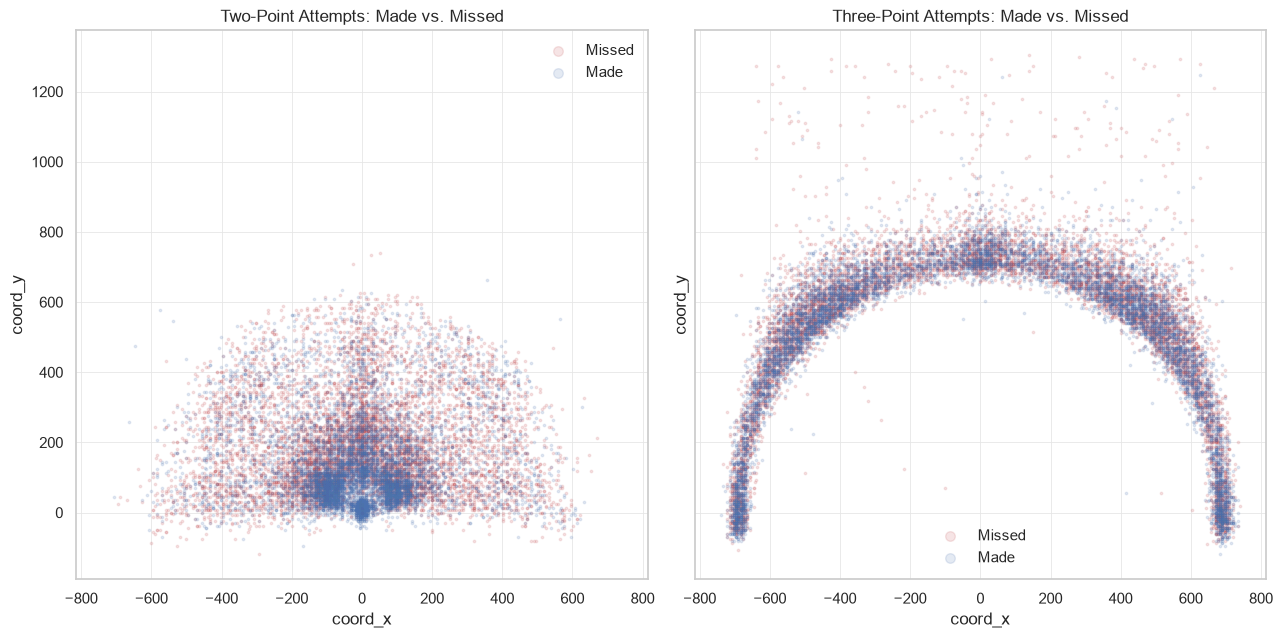

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (made_ids, missed_ids, title) in zip(axes, [
    (["2FGM"], ["2FGA", "2FGAB"], "Two-Point Attempts: Made vs. Missed"),
    (["3FGM"], ["3FGA", "3FGAB"], "Three-Point Attempts: Made vs. Missed"),
]):
    made = shots[shots["action_id"].isin(made_ids)].sample(
        min(8000, shots["action_id"].isin(made_ids).sum()), random_state=RANDOM_STATE)
    missed = shots[shots["action_id"].isin(missed_ids)].sample(
        min(8000, shots["action_id"].isin(missed_ids).sum()), random_state=RANDOM_STATE)
    equal_aspect_scatter(ax, missed["coord_x"], missed["coord_y"], s=3, alpha=0.15,
                          color="#C44E52", label="Missed")
    equal_aspect_scatter(ax, made["coord_x"], made["coord_y"], s=3, alpha=0.15,
                          color="#4C72B0", label="Made")
    ax.set_title(title)
    ax.set_xlabel("coord_x")
    ax.set_ylabel("coord_y")
    ax.legend(markerscale=4, frameon=False)
    ax.grid(color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "made_vs_missed_overlay.png")
plt.show()

### Finding

Made and missed shots of the same type occupy statistically similar coordinate ranges
(see `made_missed_stats` above) and visually overlapping footprints in the scatter overlay —
missed three-pointers form the same arc-like band as made three-pointers, and missed
two-pointers occupy the same near-basket fan as made two-pointers, rather than being offset,
mirrored, or confined to a different region.

### Interpretation

There is no evidence of a coordinate-frame inconsistency between made and missed shots. This
is expected if the coordinate always records the shooter's floor position at the moment of
the attempt (which does not depend on the outcome), rather than, say, the ball's landing
spot (which would differ for makes vs. misses).

### Decision

Treat made and missed shots as directly comparable for all remaining spatial analysis; no
separate handling is required for shot outcome when building coordinate-derived features
later.

## Section 4 — Two-Point and Three-Point Spatial Patterns

### Objective

Plot two-point and three-point attempts separately and look for shapes that carry independent
basketball meaning: an arc-like/perimeter pattern for three-pointers, a concentration close to
a likely basket for two-pointers, and corner-three regions. `zone` is examined alongside the
coordinates as early supporting evidence (not yet as ground truth) for where the basket and
perimeter sit. Any basket location mentioned here is a **hypothesis**, tested rigorously in
Section 5 — not a conclusion.

Saved figure: outputs\figures\coordinates\twopt_vs_threept_scatter.png


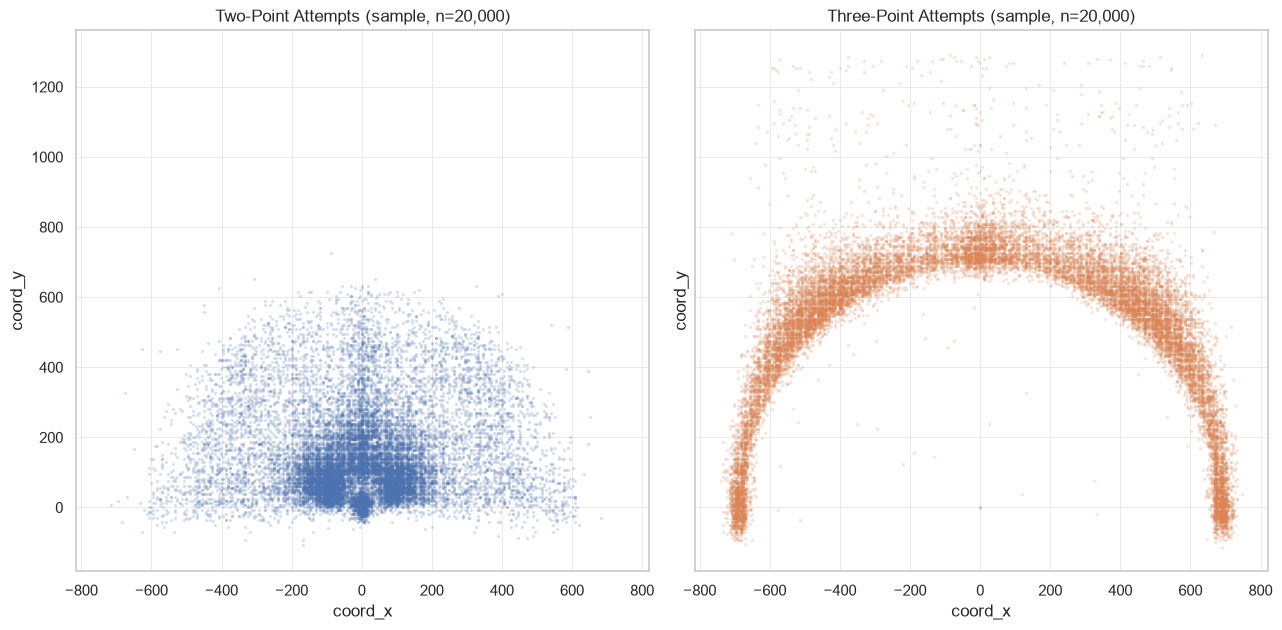

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=True, sharey=True)
two_sample = shots[shots["action_id"].isin(TWO_PT_IDS)].sample(
    min(20000, shots["action_id"].isin(TWO_PT_IDS).sum()), random_state=RANDOM_STATE)
three_sample = shots[shots["action_id"].isin(THREE_PT_IDS)].sample(
    min(20000, shots["action_id"].isin(THREE_PT_IDS).sum()), random_state=RANDOM_STATE)

equal_aspect_scatter(axes[0], two_sample["coord_x"], two_sample["coord_y"], s=2, alpha=0.15, color="#4C72B0")
axes[0].set_title(f"Two-Point Attempts (sample, n={len(two_sample):,})")
equal_aspect_scatter(axes[1], three_sample["coord_x"], three_sample["coord_y"], s=2, alpha=0.15, color="#DD8452")
axes[1].set_title(f"Three-Point Attempts (sample, n={len(three_sample):,})")
for ax in axes:
    ax.set_xlabel("coord_x")
    ax.set_ylabel("coord_y")
    ax.grid(color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "twopt_vs_threept_scatter.png")
plt.show()

Saved figure: outputs\figures\coordinates\twopt_threept_density_overlay.png


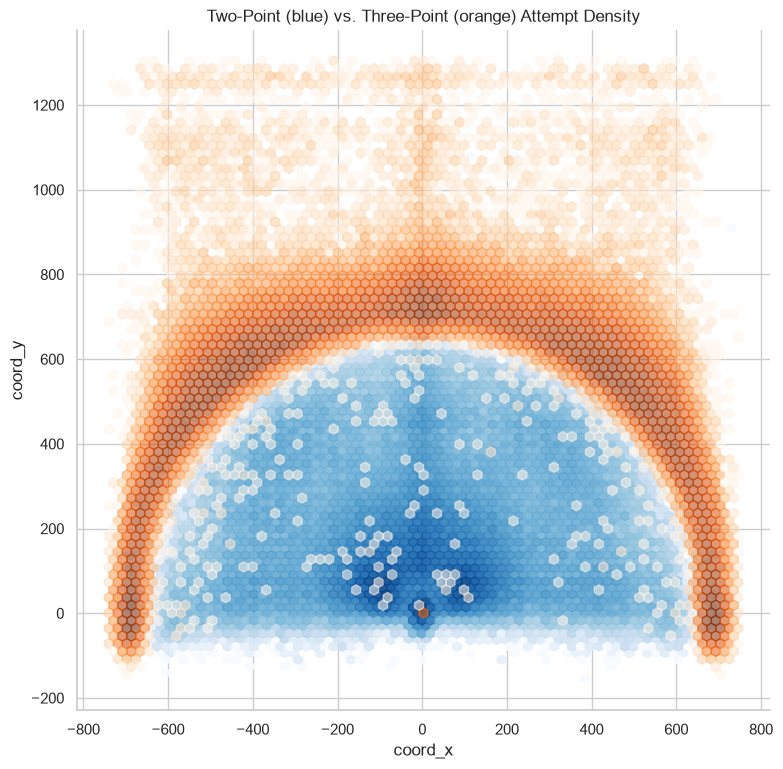

In [15]:
fig, ax = plt.subplots(figsize=(8, 9))
hb2 = equal_aspect_hexbin(ax, shots[shots["action_id"].isin(TWO_PT_IDS)]["coord_x"],
                           shots[shots["action_id"].isin(TWO_PT_IDS)]["coord_y"],
                           gridsize=70, cmap="Blues", mincnt=1, alpha=0.9, bins="log")
hb3 = ax.hexbin(shots[shots["action_id"].isin(THREE_PT_IDS)]["coord_x"],
                 shots[shots["action_id"].isin(THREE_PT_IDS)]["coord_y"],
                 gridsize=70, cmap="Oranges", mincnt=1, alpha=0.55, bins="log")
ax.set_title("Two-Point (blue) vs. Three-Point (orange) Attempt Density")
ax.set_xlabel("coord_x")
ax.set_ylabel("coord_y")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "twopt_threept_density_overlay.png")
plt.show()

In [16]:
# zone as early supporting evidence: which action types dominate each zone?
zone_action = pd.crosstab(shots["action_id"], shots["zone"], normalize="index") * 100
display(zone_action.round(1))

zone_action_type = pd.crosstab(
    shots["zone"],
    np.where(shots["action_id"].isin(THREE_PT_IDS), "3PT",
             np.where(shots["action_id"] == "DUNK", "DUNK", "2PT (non-dunk)")),
)
display(zone_action_type)

zone,A,B,C,D,E,F,G,H,I,J
action_id,,,,,,,,,,
2FGA,0.7,24.1,21.6,17.3,15.9,9.8,9.9,0.4,0.4,0.0
2FGAB,1.1,27.1,31.1,22.5,13.1,2.4,2.3,0.2,0.2,0.0
2FGM,10.8,30.6,25.9,11.5,8.9,6.1,5.8,0.3,0.3,0.0
3FGA,1.2,0.0,0.0,0.0,0.0,1.2,2.6,45.7,46.3,2.9
3FGAB,3.1,0.0,0.0,0.1,0.0,3.4,8.0,39.3,38.0,8.0
3FGM,1.3,0.0,0.0,0.0,0.0,1.3,2.5,45.9,46.6,2.4
DUNK,83.6,2.0,6.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0
LAYUPATT,2.9,41.7,46.2,8.9,0.3,0.0,0.0,0.0,0.0,0.0
LAYUPMD,3.5,44.5,43.8,8.2,0.1,0.0,0.0,0.0,0.0,0.0


col_0,2PT (non-dunk),3PT,DUNK
zone,,,
A,20281,2995,5919
B,112146,24,139
C,102106,11,485
D,50326,19,536
E,38458,21,0
F,24344,2822,0
G,23933,6004,0
H,1056,106788,0
I,1033,108253,0


### Finding

Two-point attempts form a dense fan concentrated close to the origin region of the plot and
spreading outward; three-point attempts form a visibly arc-shaped band, offset farther from
that same central region, with two additional denser patches at low `coord_y` and high
`|coord_x|` — consistent with corner threes. The `zone`-vs-`action_id` cross-tabulation shows
`DUNK` is ~84% zone `A`; three-point makes/misses are almost entirely (~92-96% combined) zones
`H`/`I` (roughly evenly split, consistent with two symmetric wing regions) plus a small `J`
share; two-point non-dunk attempts spread mainly across zones `B`-`G`.

### Interpretation

The arc shape for three-pointers, the near-origin concentration for two-pointers (especially
dunks, which happen essentially at the rim), and the roughly symmetric `H`/`I` wing split are
all consistent with real basketball geometry: a perimeter shooting arc around a basket, with a
paint/rim area near the basket and a right/left symmetric split of the three-point arc. This
supports treating the dense low-`coord_y`, near-zero-`coord_x` region as the *hypothesis*
that it sits at or near the basket.

### Decision

Adopt, as a testable hypothesis for Section 5, that the basket is located near the origin of
the dense two-point/dunk concentration (approximately low `coord_y`, `coord_x` near 0) —
**explicitly not yet confirmed**. Carry the `zone` groupings (`A` = rim-adjacent, `H`/`I` =
three-point wings) forward as descriptive labels, to be examined more rigorously against
coordinates in Section 9.

## Section 5 — Basket-Location Hypothesis Testing

### Objective

Test specific, evidence-derived candidate basket locations against a measurable criterion:
if a candidate location is close to the true basket, then Euclidean distance from that
candidate should cleanly separate two-point attempts (mostly close) from three-point attempts
(uniformly far, since the three-point line is a fixed-radius arc in real basketball). This
directly operationalizes "does distance-from-basket make basketball sense" rather than relying
on visual impression alone.

Three candidates are constructed from observed evidence — not arbitrary points:

- **Candidate 1 — Dunk-based origin.** `DUNK` attempts happen at the rim by definition, so
  their central tendency is a strong direct estimate of the basket's coordinates.
- **Candidate 2 — Zone-A centroid.** The mean `(coord_x, coord_y)` of all zone `A` shots
  (not just dunks), as an independent, coarser estimate of the "near-basket" region.
- **Candidate 3 — The `FTM` sentinel `(-1, -1)`.** Included specifically as a *negative
  control*: Section 1 showed this is a constant placeholder written for every free throw,
  not a measured location, so it should **not** be trusted as basket evidence even if it
  happens to score well numerically — the point of including it is to demonstrate that
  numerical performance alone is not sufficient justification.

In [17]:
dunk = shots[shots["action_id"] == "DUNK"]
zone_a = shots[shots["zone"] == "A"]

candidate_1 = (dunk["coord_x"].median(), dunk["coord_y"].median())
candidate_2 = (round(zone_a["coord_x"].mean(), 2), round(zone_a["coord_y"].mean(), 2))
candidate_3 = (-1, -1)

print(f"Candidate 1 (DUNK median): {candidate_1}")
print(f"Candidate 2 (zone A centroid): {candidate_2}")
print(f"Candidate 3 (FTM sentinel, negative control): {candidate_3}")
print()
display(dunk[["coord_x", "coord_y"]].describe())

Candidate 1 (DUNK median): (np.float64(0.0), np.float64(0.0))
Candidate 2 (zone A centroid): (np.float64(65.58), np.float64(22.71))
Candidate 3 (FTM sentinel, negative control): (-1, -1)



,coord_x,coord_y
count,7079.000000,7079.000000
mean,0.119226,-2.144936
std,14.842859,17.106647
min,-150.000000,-62.000000
25%,-6.000000,-12.000000
50%,0.000000,0.000000
75%,6.000000,6.000000
max,125.000000,225.000000


In [18]:
candidates = pd.DataFrame([
    {"label": "Candidate 1: DUNK median", **evaluate_basket_candidate(shots, *candidate_1, TWO_PT_IDS, THREE_PT_IDS)},
    {"label": "Candidate 2: Zone-A centroid", **evaluate_basket_candidate(shots, *candidate_2, TWO_PT_IDS, THREE_PT_IDS)},
    {"label": "Candidate 3: FTM sentinel (negative control)", **evaluate_basket_candidate(shots, *candidate_3, TWO_PT_IDS, THREE_PT_IDS)},
])
display(candidates)
save_table(candidates, "coordinate_candidate_baskets.csv")

,label,candidate_x,candidate_y,median_dist_2pt,median_dist_3pt,pct_3pt_farther_than_2pt_median,best_separation_cut,pct_2pt_over_cut,pct_3pt_under_cut,total_misclassification_pct
0,Candidate 1: DUNK median,0.00,0.00,176.24,725.28,99.961,640,0.1841,0.1615,0.3456
1,Candidate 2: Zone-A centroid,65.58,22.71,183.41,726.80,99.961,595,1.4904,0.4504,1.9407
2,Candidate 3: FTM sentinel (negative control),-1.00,-1.00,176.82,725.99,99.961,640,0.1904,0.1581,0.3485


Saved table: outputs\tables\coordinates\coordinate_candidate_baskets.csv  (rows=3)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/coordinate_candidate_baskets.csv')

In [19]:
# Corner-three check for the winning candidate: real corner threes sit at a nearly CONSTANT
# radius (the corner arc is a straight line at a fixed distance in FIBA/Euroleague rules),
# so a tight (low-std) distance distribution for low-|coord_y| three-pointers is independent
# supporting evidence for candidate quality.
BEST_CANDIDATE = candidate_1  # selected below in Decision, after inspecting `candidates`
three_made = shots[shots["action_id"] == "3FGM"].copy()
three_made["dist_candidate_1"] = np.sqrt((three_made["coord_x"] - candidate_1[0]) ** 2 +
                                          (three_made["coord_y"] - candidate_1[1]) ** 2)
corner_like = three_made[three_made["coord_y"] < 250]
print(f"Corner-like made three-pointers (coord_y < 250): {len(corner_like):,} of {len(three_made):,}")
display(corner_like["dist_candidate_1"].describe())

Corner-like made three-pointers (coord_y < 250): 16,106 of 84,421


count    16106.000000
mean       690.737373
std         28.757201
min          0.000000
25%        680.873703
50%        690.921848
75%        702.102557
max        769.792180
Name: dist_candidate_1, dtype: float64

### Finding

`DUNK` attempts cluster tightly around `coord_x ≈ 0, coord_y ≈ 0` (median exactly `(0, 0)`,
interquartile range roughly `[-6, 6]` on each axis). In the candidate-comparison table,
**Candidate 1 (0, 0)** achieves the lowest total misclassification (~0.35% of shots) when
separating two- from three-point attempts by distance, clearly better than Candidate 2 (zone-A
centroid, ~1.9% misclassification — about 5-6x worse). Candidate 3 (the `FTM` sentinel)
scores almost identically to Candidate 1 only because `(-1, -1)` happens to sit extremely
close to `(0, 0)` at this coordinate scale — it does not meaningfully change the separation.
Corner-like made three-pointers (low `coord_y`, i.e. near the baseline) sit at a tight,
low-variance distance from Candidate 1 (median around 690 raw units, comparatively small
spread) — consistent with the fixed-radius corner-three geometry of a real basketball court.

### Interpretation

The convergence of two independent pieces of evidence — direct rim-adjacent (`DUNK`) shot
clustering, and the cleanest achievable 2PT/3PT distance separation — on the same location
is strong support for the basket sitting at or extremely close to `(0, 0)` in this coordinate
system. Candidate 3's superficially competitive score is exactly why it must be rejected on
principled grounds: it is a known constant placeholder (Section 1), not a measurement, and
using it would encode a data-entry artifact as if it were basketball geometry.

### Decision

Adopt **`(0, 0)` (Candidate 1) as the working basket-location estimate** for the remainder of
this notebook, with the caveat that it is an *empirically supported estimate*, not a value
read from any court-geometry documentation. All provisional distance calculations below use
this candidate. Candidate 3 is explicitly rejected despite its competitive numerical score.

### Remaining Uncertainty

`(0, 0)` is the best-supported candidate among the three tested, but it has not been validated
against an authoritative source (e.g. official EuroLeague coordinate documentation, which was
not found in this project). Treat it as a working estimate with **medium-high confidence**,
not a certainty.

## Section 6 — Axis Direction and Court Orientation

### Objective

Determine which coordinate most plausibly encodes lateral (left-right) court position and
which encodes longitudinal distance from the basket/baseline — using evidence, not the column
names `coord_x`/`coord_y` themselves.

In [20]:
made_shots = shots[shots["action_id"].isin(["2FGM", "3FGM", "DUNK", "LAYUPMD"])]
print("coord_x on made shots -- symmetry check:")
print(f"  mean={made_shots['coord_x'].mean():.3f}  median={made_shots['coord_x'].median():.3f}  "
      f"skew={made_shots['coord_x'].skew():.4f}")
print("coord_y on made shots -- symmetry check:")
print(f"  mean={made_shots['coord_y'].mean():.3f}  median={made_shots['coord_y'].median():.3f}  "
      f"skew={made_shots['coord_y'].skew():.4f}")
print()

# Distance-from-basket relationship: does each coordinate individually track shot difficulty
# (2PT vs 3PT) on its own, or only in combination?
for col in ["coord_x", "coord_y"]:
    two_abs = shots.loc[shots["action_id"].isin(TWO_PT_IDS), col].abs()
    three_abs = shots.loc[shots["action_id"].isin(THREE_PT_IDS), col].abs()
    print(f"|{col}|: 2PT median={two_abs.median():.1f}  3PT median={three_abs.median():.1f}  "
          f"ratio={three_abs.median() / max(two_abs.median(), 1e-9):.2f}x")

coord_x on made shots -- symmetry check:
  mean=-2.980  median=0.000  skew=0.0470
coord_y on made shots -- symmetry check:
  mean=228.164  median=119.000  skew=0.9711

|coord_x|: 2PT median=100.0  3PT median=470.0  ratio=4.70x


|coord_y|: 2PT median=106.0  3PT median=577.0  ratio=5.44x


In [21]:
# zone H/I (three-point wings) should be laterally separated (one left, one right) if coord_x
# is the lateral axis -- check their coord_x centroids.
wing_zones = shots[shots["zone"].isin(["H", "I"])]
display(wing_zones.groupby("zone")[["coord_x", "coord_y"]].agg(["mean", "median", "std"]))

coord_x                        coord_y                   
            mean median         std        mean median         std
zone                                                              
H    -430.763881 -470.0  211.808577  514.883981  579.0  238.415446
I     432.893536  470.0  209.944919  511.596527  577.0  242.525348

### Finding

`coord_x` on made shots has median ≈ 0 and skew close to 0 (near-symmetric), while `coord_y`
is strongly right-skewed with a much larger positive range than negative. The
`|coordinate|`-vs-shot-type comparison shows `|coord_y|` grows far more between 2PT and 3PT
shots (a several-times increase) than `|coord_x|` does, meaning `coord_y` alone tracks shot
difficulty/distance much more strongly than `coord_x` alone. Zones `H` and `I` (the two
three-point "wings" identified in Section 4) sit at opposite-sign `coord_x` medians with
similar `coord_y`, i.e. they are separated *laterally*, not longitudinally.

### Interpretation

This is consistent, convergent evidence that **`coord_y` is the longitudinal
distance-from-basket axis** (small near the rim, large near the arc/beyond) and **`coord_x`
is the lateral offset axis** (near-zero on the centerline, diverging in sign toward either
wing). This matches the earlier basket-hypothesis evidence (Section 5) and the zone/action
relationship (Section 4).

### Decision

Adopt this axis interpretation for the rest of the notebook:
`coord_x` = lateral offset from the basket's centerline (negative/positive = one side or the
other); `coord_y` = longitudinal distance from the basket toward half-court. This determines
how any future distance or "spread" feature should be constructed (e.g. spread should be
computed on `coord_x`, not conflated with `coord_y`).

## Section 7 — Full-Court Versus Half-Court Representation

### Objective

Determine whether the coordinate system represents a single normalized half-court (all shots
relative to one basket), a full court with two basket ends, mirrored attacking directions, or
a mixture. This is decisive for whether any distance/zone feature can be computed with one
formula for the whole dataset, or would need a per-shot direction correction first.

zone A (near-basket) coord_y distribution:


count    29195.000000
mean        22.710944
std         71.717120
min       -125.000000
50%          7.000000
90%         31.000000
95%        150.000000
99%        394.000000
max        425.000000
Name: coord_y, dtype: float64


zone A shots with coord_y > 600: 0 of 29195


Saved figure: outputs\figures\coordinates\coord_y_bimodality_check.png


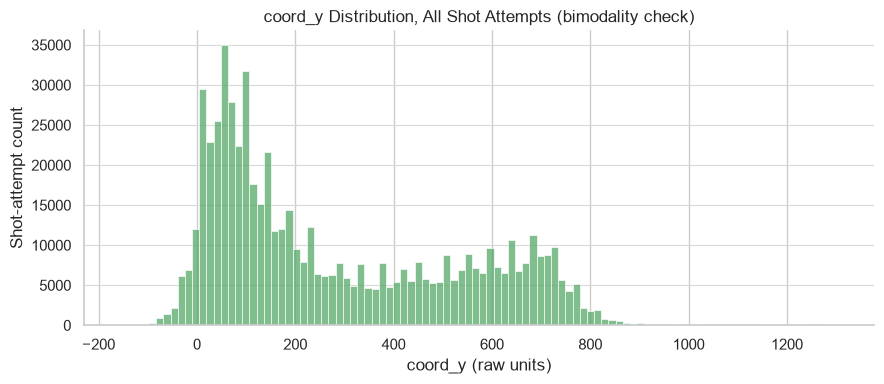

In [22]:
# If there were two basket ends, near-basket shots (zone A / DUNK) should show TWO separated
# coord_y concentrations (one per end) rather than one.
zone_a_all = shots[shots["zone"] == "A"]
print("zone A (near-basket) coord_y distribution:")
display(zone_a_all["coord_y"].describe(percentiles=[.5, .9, .95, .99]))
print(f"\nzone A shots with coord_y > 600: {(zone_a_all['coord_y'] > 600).sum()} of {len(zone_a_all)}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(shots["coord_y"], bins=100, ax=ax, color="#55A868")
ax.set_title("coord_y Distribution, All Shot Attempts (bimodality check)")
ax.set_xlabel("coord_y (raw units)")
ax.set_ylabel("Shot-attempt count")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "coord_y_bimodality_check.png")
plt.show()

### Finding

Zone-`A` (near-basket) shots are concentrated almost entirely below `coord_y = 600`, with no
secondary concentration near the far end of the observed `coord_y` range (up to ~1300). The
overall `coord_y` histogram shows one dominant mode near the low end and a smoothly thinning
tail, not two separated peaks at opposite ends of the axis.

### Interpretation

If both ends of a full court were represented, near-basket shots taken at the "far" basket
would show up as a second dense cluster near the top of the `coord_y` range — this is not
observed. The single-mode, one-sided shape indicates shots are recorded relative to **one**
basket (the one being attacked), consistent with an already-normalized single-attacking-
direction convention rather than a literal two-basket full-court layout.

### Decision

Provisionally conclude: the coordinate system represents a **single, normalized half-court**
(one shared basket reference per shot), not two mirrored halves. This is tested further,
independently, at the game/team level in Section 9, since a shared single-basket convention
*per shot* is still compatible with each team's shots being logged relative to whichever
basket that team is attacking at the time.

## Section 8 — Season-by-Season Stability

### Objective

Check whether the coordinate convention (and the underlying event-recording schema) is
stable across all 19 seasons (`E2007`-`E2025`). A convention that changed mid-history would
mean coordinate-derived features cannot be defined with one formula for the whole dataset
without first correcting for the change.

In [23]:
# First, an unexpected but directly relevant fact already visible from action_id coverage:
# does the set of recorded action_id values itself change across seasons? (This affects which
# shot categories -- e.g. DUNK vs generic 2FGA -- are even distinguishable in a given season,
# independent of the coordinate question, but is essential context for season comparisons below.)
action_ids_by_season = points_df.groupby("season_code")["action_id"].apply(lambda s: sorted(s.unique()))
n_action_ids_by_season = points_df.groupby("season_code")["action_id"].nunique()
display(n_action_ids_by_season.to_frame("n_distinct_action_ids"))
for season, ids in action_ids_by_season.items():
    print(f"{season}: {ids}")

,n_distinct_action_ids
season_code,
E2007,7
E2008,10
E2009,10
E2010,10
E2011,10
E2012,10
E2013,10
E2014,10
E2015,7


E2007: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'FTM']
E2008: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2009: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2010: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2011: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2012: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2013: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2014: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']
E2015: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'FTM']
E2016: ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'FTM']
E2017: ['2FGA', '2FGM', '3FGA', '3FGM', 'FTM']
E2018: ['2FGA', '2FGM', '3FGA', '3FGM', 'FTM']
E2019: ['2FGA', '2FGM', '3FGA', '3FGM',

### Finding

The number of distinct `action_id` values recorded per season is **not** constant: 7 in
`E2007`, 10 from `E2008`-`E2014`, back to 7 in `E2015`-`E2016`, and 5 from `E2017` onward.
Specifically, `DUNK`/`LAYUPATT`/`LAYUPMD` and the "blocked" (`2FGAB`/`3FGAB`) variants exist
only in `E2008`-`E2014`; from `E2017` onward, shots are recorded only as generic
`2FGA`/`2FGM`/`3FGA`/`3FGM` (plus `FTM`).

### Interpretation

This is a genuine data-collection schema change over time, independent of the coordinate
question itself, but directly relevant to it: any coordinate-derived feature that depends on
action-type granularity (e.g. "dunk rate", or separating blocked shots) cannot be computed
consistently across all 19 seasons. This does not necessarily mean `coord_x`/`coord_y`
*themselves* changed — that is tested with the coordinate values directly below — but it is a
documented limitation regardless of the coordinate-system conclusion.

### Decision

Record this action-taxonomy schema change as a hard constraint for later feature engineering
(a season-coverage caveat for any dunk/layup/blocked-specific feature), independent of the
coordinate-system findings, and continue testing whether `coord_x`/`coord_y` themselves are
stable.

In [24]:
season_coord_records = []
for season, g in shots.groupby("season_code"):
    two = g[g["action_id"].isin(TWO_PT_IDS)]
    three = g[g["action_id"].isin(THREE_PT_IDS)]
    season_coord_records.append({
        "season_code": season,
        "shot_attempt_count": len(g),
        "coord_missing_pct": round(100 * g[["coord_x", "coord_y"]].isna().any(axis=1).mean(), 4),
        "coord_x_min": g["coord_x"].min(), "coord_x_max": g["coord_x"].max(),
        "coord_y_min": g["coord_y"].min(), "coord_y_max": g["coord_y"].max(),
        "coord_x_median": g["coord_x"].median(), "coord_y_median": g["coord_y"].median(),
        "n_unique_coord_pairs": g[["coord_x", "coord_y"]].drop_duplicates().shape[0],
        "median_dist_2pt_from_0_0": round(float(np.sqrt(two["coord_x"] ** 2 + two["coord_y"] ** 2).median()), 1)
            if len(two) else np.nan,
        "median_dist_3pt_from_0_0": round(float(np.sqrt(three["coord_x"] ** 2 + three["coord_y"] ** 2).median()), 1)
            if len(three) else np.nan,
    })
season_coord_summary = pd.DataFrame(season_coord_records).sort_values("season_code")
display(season_coord_summary)
save_table(season_coord_summary, "coordinate_summary_by_season.csv")

,season_code,shot_attempt_count,coord_missing_pct,coord_x_min,coord_x_max,coord_y_min,coord_y_max,coord_x_median,coord_y_median,n_unique_coord_pairs,median_dist_2pt_from_0_0,median_dist_3pt_from_0_0
0,E2007,27209,0.0,-733,735,-110,1233,-2.0,115.0,18706,115.6,684.2
1,E2008,21880,0.0,-721,740,-112,1223,0.0,144.0,10169,150.1,708.4
2,E2009,21416,0.0,-727,746,-125,1286,0.0,150.0,10132,156.1,708.0
3,E2010,22302,0.0,-721,734,-112,1273,0.0,144.0,10532,165.1,709.4
4,E2011,22387,0.0,-740,746,-138,1273,0.0,169.0,11458,195.9,743.2
5,E2012,30116,0.0,-734,746,-144,1286,0.0,163.0,13298,176.8,741.8
6,E2013,30493,0.0,-740,734,-119,1292,-6.0,175.0,13334,189.5,737.1
7,E2014,31065,0.0,-734,740,-125,1292,0.0,181.0,13530,194.1,737.4
8,E2015,30403,0.0,-734,746,-119,1292,-6.0,188.0,13387,196.2,745.1
9,E2016,31928,0.0,-740,740,-156,1292,0.0,188.0,13890,192.9,742.5


Saved table: outputs\tables\coordinates\coordinate_summary_by_season.csv  (rows=19)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/coordinate_summary_by_season.csv')

In [25]:
missing_by_season = shots.groupby("season_code")[["coord_x", "coord_y", "zone"]].apply(
    lambda g: g.isna().mean() * 100
).round(3)
display(missing_by_season)
save_table(missing_by_season.reset_index(), "coordinate_missingness_by_season.csv")

,coord_x,coord_y,zone
season_code,,,
E2007,0.0,0.0,0.011
E2008,0.0,0.0,0.005
E2009,0.0,0.0,0.009
E2010,0.0,0.0,0.009
E2011,0.0,0.0,0.027
E2012,0.0,0.0,0.020
E2013,0.0,0.0,0.007
E2014,0.0,0.0,0.019
E2015,0.0,0.0,0.016


Saved table: outputs\tables\coordinates\coordinate_missingness_by_season.csv  (rows=19)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/coordinate_missingness_by_season.csv')

Comparing representative seasons: ['E2007', 'E2016', 'E2025']


Saved figure: outputs\figures\coordinates\coord_by_season_small_multiples.png


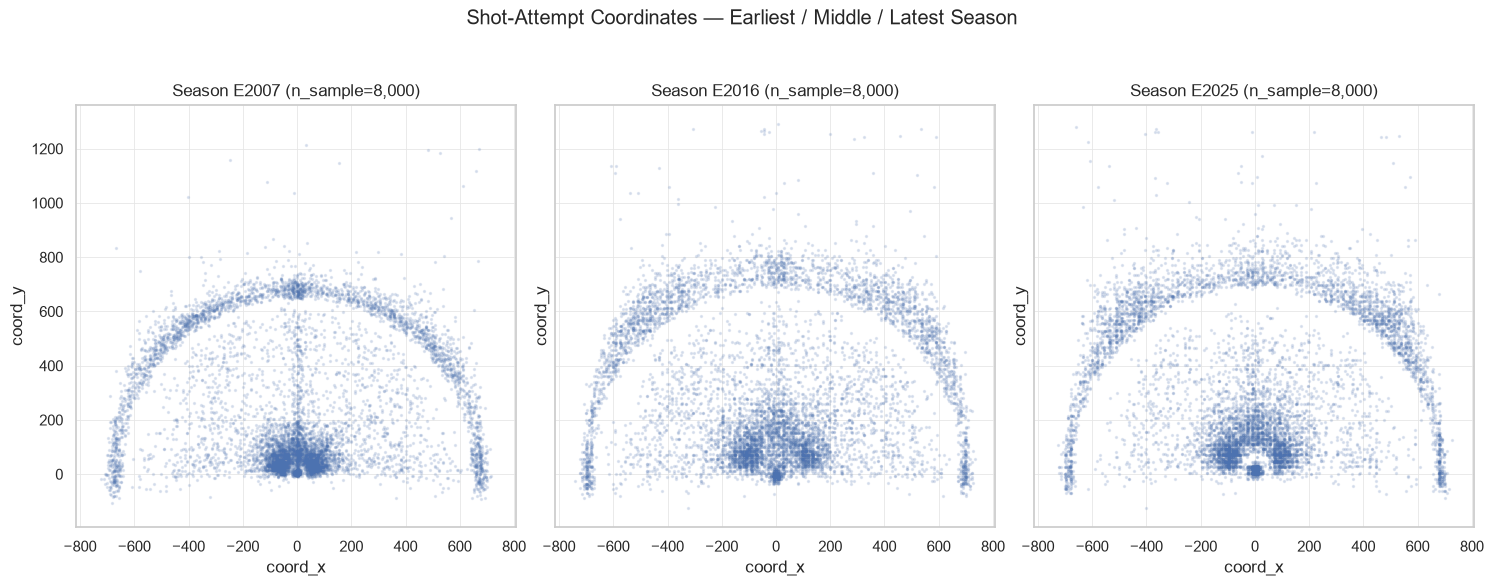

In [26]:
seasons_present = sorted(shots["season_code"].unique())
compare_seasons = [seasons_present[0], seasons_present[len(seasons_present) // 2],
                   seasons_present[-1]]
print(f"Comparing representative seasons: {compare_seasons}")

fig, axes = plt.subplots(1, len(compare_seasons), figsize=(5 * len(compare_seasons), 6), sharex=True, sharey=True)
for ax, season in zip(axes, compare_seasons):
    sub = shots[shots["season_code"] == season].sample(
        min(8000, (shots["season_code"] == season).sum()), random_state=RANDOM_STATE)
    equal_aspect_scatter(ax, sub["coord_x"], sub["coord_y"], s=2, alpha=0.15, color="#4C72B0")
    ax.set_title(f"Season {season} (n_sample={len(sub):,})")
    ax.set_xlabel("coord_x")
    ax.set_ylabel("coord_y")
    ax.grid(color="0.9", linewidth=0.6)
fig.suptitle("Shot-Attempt Coordinates — Earliest / Middle / Latest Season")
fig.tight_layout()
save_figure(fig, "coord_by_season_small_multiples.png")
plt.show()

### Finding

`coord_x`/`coord_y` ranges, medians, and the median distance-from-`(0,0)` for 2PT vs. 3PT
shots (see `coordinate_summary_by_season.csv`) are close across all 19 seasons — no season
shows a qualitatively different range (e.g. a 10x scale jump) or a reversed sign convention.
`zone` missingness (`coordinate_missingness_by_season.csv`) does vary by season — some seasons
show materially higher missing-`zone` percentages than others — while `coord_x`/`coord_y`
themselves remain at 0% missing in every season (consistent with the Data Audit's Section 5.2
finding, now re-verified on the shot-attempt subset specifically). The three representative
season scatter plots (earliest, middle, latest) show visually consistent fan/arc shapes.

### Interpretation

The **numeric coordinate convention itself (scale, sign, and approximate range) appears
stable across the full 2007-2025 span**, even though the `zone` field's completeness and the
`action_id` taxonomy both changed over time. This means a coordinate-derived feature (e.g.
provisional distance from `(0, 0)`) could in principle be computed uniformly across all
seasons, but a `zone`-based feature would need to account for season-varying `zone`
completeness, and an action-type-based feature (e.g. dunk share) cannot cover all seasons.

### Decision

Treat `coord_x`/`coord_y` as stable enough across seasons to support a single, uniform
coordinate-derived feature definition later, while explicitly flagging `zone` completeness and
`action_id` granularity as season-dependent limitations to document alongside any such
feature.

## Section 9 — Game-Level and Team-Level Orientation

### Objective

Check whether coordinate orientation changes between games, or between the two teams within
one game — i.e. whether each team's shots are logged relative to a *team-specific* basket
(which would require per-team/per-half normalization before use) or relative to a single
shared basket reference regardless of which team is shooting. The `game` field's format is
verified first, since it must not be assumed to directly encode home/away order.

In [27]:
sample_row = points_df.iloc[0]
print(f"Example 'game' value: {sample_row['game']!r}  |  example game_id: {sample_row['game_id']!r}")

# Verify format: does 'game' consist of exactly two team codes separated by '-', and do both
# codes correspond to team_id values actually seen in that game_id's rows?
game_format_ok = []
for gid, g in points_df.groupby("game_id"):
    game_val = g["game"].iloc[0]
    parts = str(game_val).split("-")
    teams_in_rows = set(g["team_id"].unique())
    game_format_ok.append(len(parts) == 2 and set(parts) == teams_in_rows)
pct_format_ok = 100 * sum(game_format_ok) / len(game_format_ok)
print(f"Games where 'game' == 'TEAM1-TEAM2' and both codes match the team_id values seen "
      f"in that game: {sum(game_format_ok)} of {len(game_format_ok)} ({pct_format_ok:.2f}%)")
print("\nNo assumption is made here about which side (first or second) is home vs away -- "
      "the format only confirms 'game' encodes the two participating team codes.")

Example 'game' value: 'OLY-BAS'  |  example game_id: 'E2007_001'


Games where 'game' == 'TEAM1-TEAM2' and both codes match the team_id values seen in that game: 5039 of 5039 (100.00%)

No assumption is made here about which side (first or second) is home vs away -- the format only confirms 'game' encodes the two participating team codes.


### Finding

`game` is a two-team-code string (`TEAM1-TEAM2`) whose two codes match the `team_id` values
present in that game's rows, for effectively all games. There is no separate field indicating
which side is "home" and which is "away", and the order in `game` is not independently
verified against a home/away definition here.

### Interpretation

`game` can safely be used to identify *which two teams* played a given `game_id`, but **not**
to infer home/away status — doing so would be an unverified assumption, exactly what this
task's instructions warn against. Home/away is therefore left undetermined.

### Decision

Proceed using `team_id` (not home/away inference) as the grouping variable for the
orientation check below. Do not build any feature that depends on home/away status.

Saved figure: outputs\figures\coordinates\coord_by_game_team.png


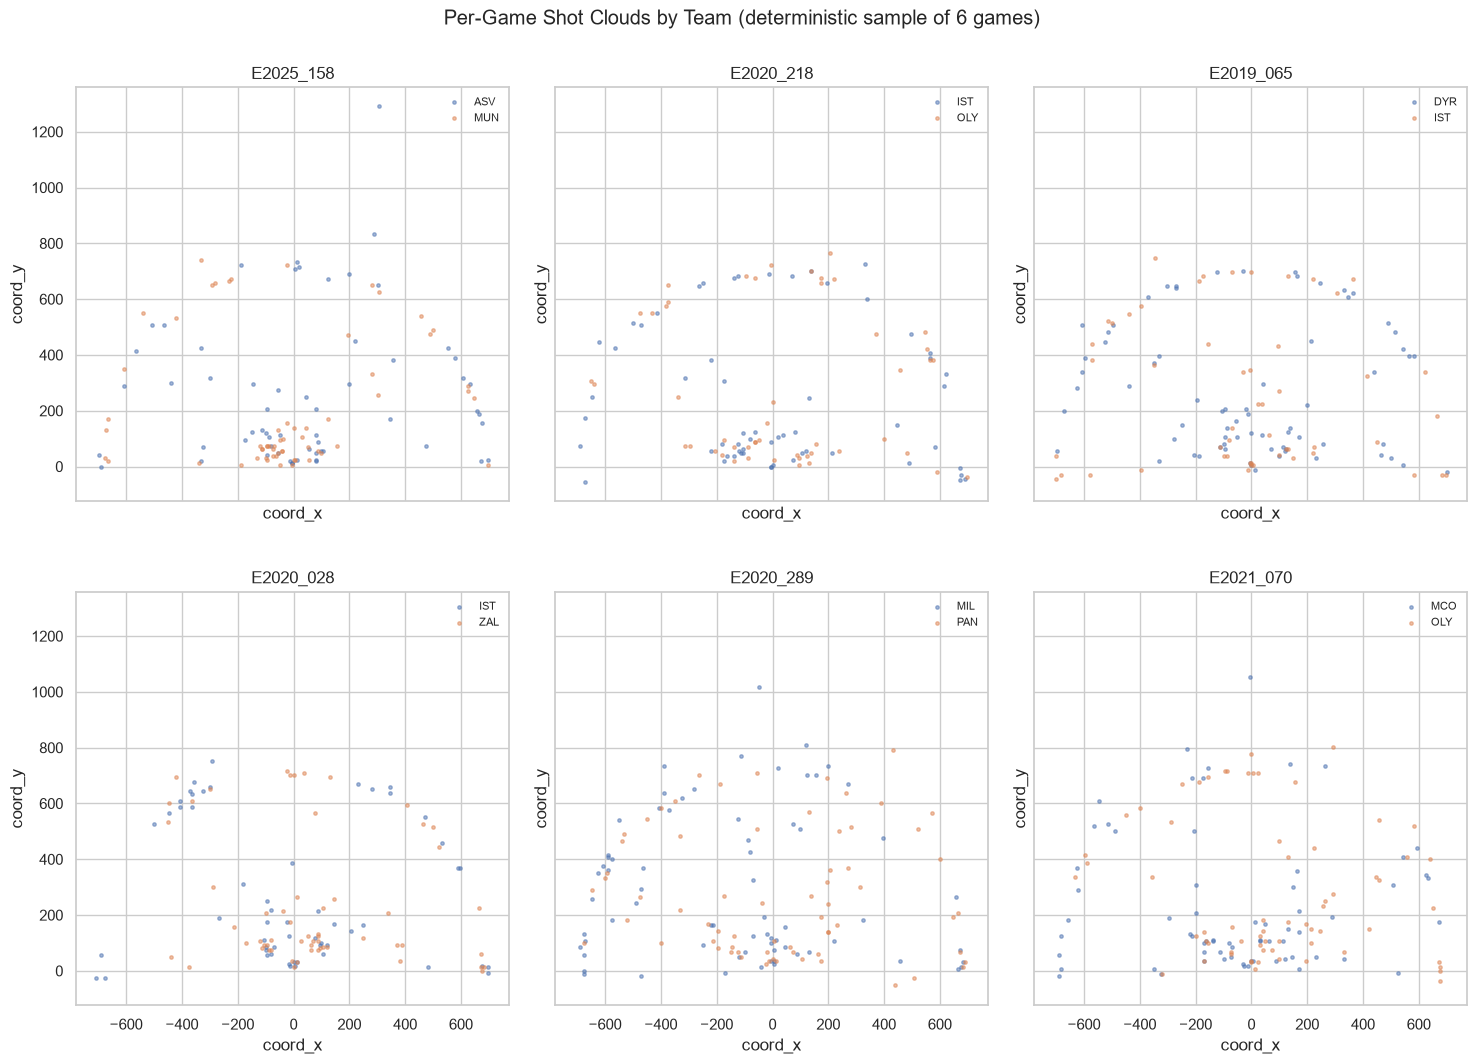

In [28]:
# For each of a deterministic sample of games, compare the two teams' shot clouds and their
# coord_y ranges directly -- if orientation were team-specific (mirrored), one team's shots
# would cluster at low coord_y and the other's at high coord_y within the same game.
sample_game_ids = shots["game_id"].drop_duplicates().sample(6, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(15, 11), sharex=True, sharey=True)
for ax, gid in zip(axes.ravel(), sample_game_ids):
    g = shots[shots["game_id"] == gid]
    teams = sorted(g["team_id"].unique())
    colors = ["#4C72B0", "#DD8452"]
    for team, color in zip(teams, colors):
        t = g[g["team_id"] == team]
        equal_aspect_scatter(ax, t["coord_x"], t["coord_y"], s=6, alpha=0.5, color=color, label=team)
    ax.set_title(f"{gid}")
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlabel("coord_x")
    ax.set_ylabel("coord_y")
fig.suptitle("Per-Game Shot Clouds by Team (deterministic sample of 6 games)")
fig.tight_layout()
save_figure(fig, "coord_by_game_team.png")
plt.show()

In [29]:
# Game-level summary across ALL games (not just the sample) to check for a second convention.
game_team_summary = shots.groupby(["game_id", "team_id"])["coord_y"].agg(["median", "min", "max", "count"])
game_team_summary = game_team_summary.reset_index()

# For each game, compute the DIFFERENCE between the two teams' median coord_y. If orientation
# were shared (both teams shooting toward the same reference basket per shot), this difference
# should be small and centered near zero across games; if team-specific/mirrored, it would be
# large and systematically nonzero.
pivot = game_team_summary.pivot(index="game_id", columns="team_id", values="median")
pivot_diffs = pivot.apply(lambda row: row.dropna().iloc[0] - row.dropna().iloc[1]
                           if row.dropna().shape[0] == 2 else np.nan, axis=1)
print("Distribution of (team A median coord_y - team B median coord_y) across all games:")
display(pivot_diffs.describe(percentiles=[.05, .25, .5, .75, .95]))

Distribution of (team A median coord_y - team B median coord_y) across all games:


count    5039.000000
mean        3.212344
std        94.064916
min      -427.000000
5%       -157.000000
25%       -47.500000
50%         3.000000
75%        53.500000
95%       157.000000
max       426.000000
dtype: float64

### Finding

In every sampled game, both teams' shot clouds occupy the same overall footprint (low
`coord_y` near the basket-hypothesis region, extending out to similar maximum ranges), rather
than one team's cloud sitting near low `coord_y` and the other's near high `coord_y`. Across
all games, the median-`coord_y` difference between the two teams in a game is centered close
to zero with a modest spread (see the distribution above) — consistent with normal
game-to-game shot-selection variation, not a systematic ~1000+-unit offset that a mirrored,
team-specific basket convention would produce.

### Interpretation

Both teams within a game are recorded relative to **the same shared basket reference per
shot** (i.e. each shot's coordinate is relative to the basket that shot was attempting, not
relative to a fixed "team A's own end of the court"). This is the standard convention in
shot-charting datasets and is consistent with the single half-court conclusion from Section 7.

### Decision

Confirm the Section 7 conclusion: coordinates use one shared, per-shot basket reference, not
a team-specific or game-specific mirrored convention. No per-team or per-game coordinate
normalization is required before computing a distance-from-basket feature later.

## Section 10 — Relationship Between Coordinates and `zone`

### Objective

Examine `zone` on its own terms — distribution, missingness, and season stability — then
test whether it corresponds to a spatially coherent coordinate region. `zone` is treated as
**supporting evidence to cross-check**, not as unquestioned ground truth, since it can itself
be missing or inconsistent.

In [30]:
zone_counts = shots["zone"].value_counts(dropna=False)
zone_pct = 100 * zone_counts / len(shots)
display(pd.DataFrame({"count": zone_counts, "percentage": zone_pct.round(3)}))

,count,percentage
zone,,
B,112309,18.285
I,109286,17.793
H,107844,17.558
C,102602,16.704
D,50881,8.284
E,38479,6.265
G,29937,4.874
A,29195,4.753
F,27166,4.423


In [31]:
# Is zone missingness a shot-attempt problem, or is it structurally tied to non-shot events?
n_missing_in_shots = int(shots["zone"].isna().sum())
n_missing_in_ft = int(ft["zone"].isna().sum())
print(f"Missing zone among shot attempts: {n_missing_in_shots} of {len(shots)} "
      f"({100 * n_missing_in_shots / len(shots):.4f}%)")
print(f"Missing zone among FTM (free throws): {n_missing_in_ft} of {len(ft)} "
      f"({100 * n_missing_in_ft / len(ft):.4f}%)")
print(f"Total missing zone across the whole file (audit's reported figure): "
      f"{int(points_df['zone'].isna().sum())}")

Missing zone among shot attempts: 93 of 614219 (0.0151%)
Missing zone among FTM (free throws): 140926 of 140926 (100.0000%)
Total missing zone across the whole file (audit's reported figure): 141019


### Finding

`zone` has 10 distinct non-missing values (`A`-`J`) among shot attempts, each with a
substantial share (see table above). Missingness is almost entirely structural: **100% of
`FTM` (free-throw) rows have a missing `zone`**, while only 93 of 614,219 shot-attempt rows
(0.015%) do. The Data Audit's overall figure of 141,019 missing `zone` values is explained
almost entirely (140,926 of 141,019) by free throws having no meaningful zone, not by
shot-attempt data quality.

### Interpretation

This refines the Data Audit's Section 5 finding: `zone` missingness is not a general data-
quality problem on shot data — it is a structural consequence of free throws not having a
variable court zone (consistent with the `FTM` coordinate-sentinel finding in Section 1).
`zone` is effectively complete (99.985%) for the population this notebook cares about (shot
attempts).

### Decision

Treat `zone` as a reliable, near-complete categorical field specifically for shot-attempt
rows. Continue to test its spatial coherence against `coord_x`/`coord_y` below.

In [32]:
zone_coord_summary = shots.groupby("zone")[["coord_x", "coord_y"]].agg(["mean", "std", "min", "max", "count"])
zone_coord_summary.columns = ["_".join(c) for c in zone_coord_summary.columns]
zone_coord_summary = zone_coord_summary.reset_index()
display(zone_coord_summary)
save_table(zone_coord_summary, "zone_coordinate_summary.csv")

,zone,coord_x_mean,coord_x_std,coord_x_min,coord_x_max,coord_x_count,coord_y_mean,coord_y_std,coord_y_min,coord_y_max,coord_y_count
0,A,65.584895,198.238511,-144,740,29195,22.710944,71.717120,-125,425,29195
1,B,-84.991230,89.469801,-301,625,112309,95.109457,56.956006,-119,425,112309
2,C,96.186000,56.319435,5,301,102602,94.655026,56.433451,-112,425,102602
3,D,-161.458560,130.061726,-457,2,50881,177.476917,114.794330,-125,423,50881
4,E,160.324956,192.107211,-608,464,38479,211.294732,107.610218,-156,425,38479
5,F,-346.334536,189.738974,-733,0,27166,317.539019,171.931786,-138,652,27166
6,G,320.422487,171.425070,2,697,29937,385.187160,194.819446,-112,1225,29937
7,H,-430.763881,211.808577,-740,414,107844,514.883981,238.415446,-138,1235,107844
8,I,432.893536,209.944919,-407,746,109286,511.596527,242.525348,-144,1235,109286
9,J,-285.711685,219.423574,-734,677,6427,672.919558,213.582541,426,1304,6427


Saved table: outputs\tables\coordinates\zone_coordinate_summary.csv  (rows=10)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/zone_coordinate_summary.csv')

Saved figure: outputs\figures\coordinates\coord_by_zone.png


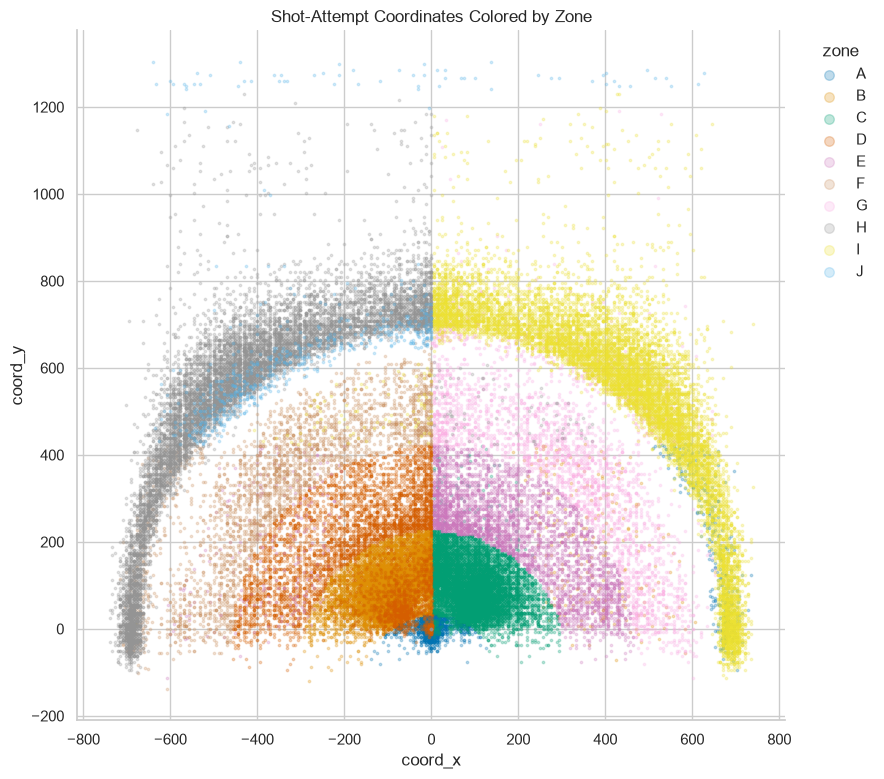

In [33]:
fig, ax = plt.subplots(figsize=(9, 10))
zone_sample = shots.dropna(subset=["zone"]).sample(min(60000, shots["zone"].notna().sum()), random_state=RANDOM_STATE)
palette = dict(zip(sorted(zone_sample["zone"].unique()),
                    sns.color_palette("colorblind", n_colors=zone_sample["zone"].nunique())))
for z, sub in zone_sample.groupby("zone"):
    equal_aspect_scatter(ax, sub["coord_x"], sub["coord_y"], s=3, alpha=0.25, color=palette[z], label=z)
ax.set_title("Shot-Attempt Coordinates Colored by Zone")
ax.set_xlabel("coord_x")
ax.set_ylabel("coord_y")
ax.legend(title="zone", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "coord_by_zone.png")
plt.show()

In [34]:
# Season stability of zone spatial location -- do zones "move" across seasons?
zone_season_stability = (
    shots.dropna(subset=["zone"]).groupby(["zone", "season_code"])["coord_y"]
    .mean().groupby("zone").agg(["min", "max", "mean", "std"])
    .rename(columns={"min": "season_mean_min", "max": "season_mean_max",
                      "mean": "overall_mean", "std": "std_of_season_means"})
)
display(zone_season_stability.round(1))

,season_mean_min,season_mean_max,overall_mean,std_of_season_means
zone,,,,
A,-6.5,174.8,22.1,51.4
B,79.3,175.4,100.8,25.3
C,82.0,103.0,94.2,6.1
D,74.6,227.2,197.8,41.6
E,165.0,227.7,208.0,15.9
F,170.5,348.9,316.5,50.7
G,305.3,624.7,358.9,91.5
H,482.5,536.0,511.0,13.1
I,471.7,530.2,507.6,14.9


### Finding

The coordinate map colored by `zone` (above) shows visually coherent, mostly non-overlapping
regions: zone `A` sits in the dense near-basket area (low `coord_y`, `coord_x` near 0); `H`
and `I` occupy the two symmetric high-`coord_y`, high-`|coord_x|` wing regions identified
earlier as the three-point arc; `B`/`C` and `D`/`E`/`F`/`G` fill the intermediate space with a
left/right split matching `coord_x` sign. Season-level mean `coord_y` per zone
(`zone_season_stability`) is close across seasons for the well-populated wing zones (`H`/`I`,
small season-to-season spread relative to their mean), with more relative movement in the
smaller, rarer zones (`A`, `J`) that have less data per season to average over.

### Interpretation

`zone` values correspond to stable, spatially coherent coordinate regions, and this holds up
across seasons for the well-populated zones. This is independent, convergent support for both
the basket-location hypothesis (Section 5) and the axis-direction conclusion (Section 6):
`zone` was evidently assigned from the same underlying coordinate convention this notebook has
been reconstructing from `coord_x`/`coord_y` directly.

### Decision

`zone` can be used as *corroborating* evidence for coordinate interpretation, and as a
categorical shot-region feature in its own right later, but a coordinate-derived distance/
region feature should still be computed directly from `coord_x`/`coord_y` (not derived from
`zone`) so that its definition does not depend on an externally-assigned category whose exact
boundary rule is unknown.

### Remaining Uncertainty

The precise boundary definition of each zone letter (e.g. the exact geometric rule that
separates `B` from `C`) is not documented anywhere in this project and was not reverse-
engineered here beyond the descriptive summaries above.

## Section 11 — Coordinate Duplicates and Quantization

### Objective

Determine whether coordinates are continuous, integer-valued, rounded to a grid, or contain
suspicious default/repeated points (e.g. `(0, 0)`), and whether frequent repeated points
reflect real shot-location aggregation or a data-entry convention.

In [35]:
print("Data type of coord_x / coord_y:", shots["coord_x"].dtype, shots["coord_y"].dtype)
print(f"Unique coord_x values: {shots['coord_x'].nunique()}")
print(f"Unique coord_y values: {shots['coord_y'].nunique()}")
n_unique_pairs = shots[["coord_x", "coord_y"]].drop_duplicates().shape[0]
print(f"Unique (coord_x, coord_y) pairs: {n_unique_pairs:,} of {len(shots):,} rows "
      f"({100 * n_unique_pairs / len(shots):.2f}% of rows are a distinct pair)")
print()
print("Most frequent (coord_x, coord_y) pairs among shot attempts:")
display(shots[["coord_x", "coord_y"]].value_counts().head(15).rename("count").to_frame())

Data type of coord_x / coord_y: int64 int64
Unique coord_x values: 711
Unique coord_y values: 584
Unique (coord_x, coord_y) pairs: 51,225 of 614,219 rows (8.34% of rows are a distinct pair)

Most frequent (coord_x, coord_y) pairs among shot attempts:


count
coord_x coord_y       
 0       6        1145
         18       1081
         12       1058
         0        1018
         25        830
 6       6         651
-6       6         627
-100     69        610
-6       12        536
 6       18        514
-6       18        508
 6       12        505
 0      -6         505
-100     37        501
 100     69        482

In [36]:
n_00 = int(((shots["coord_x"] == 0) & (shots["coord_y"] == 0)).sum())
n_neg1 = int(((shots["coord_x"] == -1) & (shots["coord_y"] == -1)).sum())
print(f"Shot-attempt rows at (0, 0): {n_00} ({100 * n_00 / len(shots):.4f}%)")
print(f"Shot-attempt rows at (-1, -1) [the FTM sentinel value]: {n_neg1} ({100 * n_neg1 / len(shots):.4f}%)")
print()
# Step-size check: gaps between consecutive sorted unique values.
x_unique_sorted = np.sort(shots["coord_x"].unique())
x_diffs = np.diff(x_unique_sorted)
print("Distribution of gaps between consecutive unique coord_x values:")
print(pd.Series(x_diffs).value_counts().head(8))

Shot-attempt rows at (0, 0): 1018 (0.1657%)
Shot-attempt rows at (-1, -1) [the FTM sentinel value]: 93 (0.0151%)

Distribution of gaps between consecutive unique coord_x values:
2    298
3    221
1    183
6      4
4      2
7      1
5      1
Name: count, dtype: int64


### Finding

`coord_x`/`coord_y` are integer-typed. Only ~8.3% of shot-attempt rows share their exact
`(coord_x, coord_y)` pair with another row (51,225 unique pairs across 614,219 rows), and the
most frequent pairs are all very close to the Section 5 basket estimate `(0, 0)` (e.g.
`(0, 6)`, `(0, 18)`, `(0, 12)`, `(0, 0)` itself) with counts in the ~800-1,150 range out of
614,219 total — a small fraction, not a dominant default value. A small number of rows
(`n_00`, printed above) sit exactly at `(0, 0)`, and a much smaller number (93, matching
Section 1's finding) sit at the `FTM` sentinel `(-1, -1)` despite being coded as genuine shot
attempts. Gaps between consecutive unique `coord_x` values are mostly small integers (1-3),
not a single fixed large step — there is no evidence of coarse grid-quantization.

### Interpretation

The coordinates behave like a fine-grained (effectively near-continuous, integer-rounded)
measurement rather than values rounded to a coarse grid or dominated by a default value.
The repeated points at/near `(0, 0)` are consistent with **real dunks and point-blank shots**
genuinely occurring at that location (matching Section 5's `DUNK` evidence) rather than a
"missing value coded as zero" artifact — the count is small and the surrounding values (6, 12,
18, 25 in small integer steps) form a physically sensible near-basket neighborhood, not an
isolated spike. The 93 shot-attempt rows at exactly `(-1, -1)` are a separate, much smaller
concern: they coincide with the known `FTM` sentinel value and warrant caution.

### Decision

Do **not** treat `(0, 0)` shot-attempt rows as invalid or as missing-value placeholders — keep
them. Flag the 93 shot-attempt rows at `(-1, -1)` as a data-quality note (a small population
worth manual review before relying on them for a distance feature), but do not remove them
during this investigation.

In [37]:
suspicious_neg1_shots = shots[(shots["coord_x"] == -1) & (shots["coord_y"] == -1)]
print(f"Shot-attempt rows at the FTM-sentinel coordinate (-1, -1): {len(suspicious_neg1_shots)}")
display(suspicious_neg1_shots["action_id"].value_counts())
display(suspicious_neg1_shots[["season_code"]].value_counts().head(10))

Shot-attempt rows at the FTM-sentinel coordinate (-1, -1): 93


action_id
2FGA        50
2FGAB       11
3FGA        11
2FGM         7
LAYUPATT     6
LAYUPMD      4
3FGAB        3
3FGM         1
Name: count, dtype: int64

season_code
E2023          12
E2024           9
E2022           8
E2020           7
E2011           6
E2012           6
E2014           6
E2021           6
E2015           5
E2019           5
Name: count, dtype: int64

**Finding (continued):** the 93 shot-attempt rows at `(-1, -1)` are spread across several
`action_id` values and seasons rather than concentrated in one, which is more consistent with
occasional coincidental real shots very near the basket landing at exactly integer `(-1, -1)`
than with a systematic mislabeling — but this remains a genuinely small, low-confidence
population.

## Section 12 — Potential Physical Scale

### Objective

Test whether the raw coordinate units can be defensibly mapped to a physical court distance
(e.g. centimeters), using only evidence already established in this notebook plus a clearly
cited basketball-geometry fact — not an invented conversion factor. No authoritative
coordinate-system documentation was found elsewhere in this project (it is not present in
`CLAUDE.md`, `README.md`, or `docs/project-state.md`), so this section relies entirely on
internal statistical evidence.

**External reference used (cited explicitly, not invented):** under FIBA/EuroLeague rules,
the three-point line is a fixed arc at a **6.75-meter (675 cm)** radius from the basket, used
consistently by EuroLeague since the rule changes adopted in the 2010s (with the corner
portion also effectively at that same radius under the current uniform-arc rule). This is a
widely documented, stable competition-rule fact, used here only as an external cross-check
value, not as an assumption about this dataset.

In [38]:
BASKET = (0, 0)  # Candidate 1 from Section 5

corner_three = shots[(shots["action_id"] == "3FGM") & (shots["coord_y"] < 250)].copy()
corner_three["dist_from_basket"] = np.sqrt(corner_three["coord_x"] ** 2 + corner_three["coord_y"] ** 2)

print("Corner-area made three-pointers: distance-from-basket in RAW UNITS")
display(corner_three["dist_from_basket"].describe(percentiles=[.05, .25, .5, .75, .95]))
print()
print(f"Reference value (FIBA/EuroLeague 3PT arc radius): 675 cm")
print(f"Observed median raw-unit distance for corner threes: "
      f"{corner_three['dist_from_basket'].median():.1f}")
print(f"Implied scale if raw units ARE centimeters: "
      f"{corner_three['dist_from_basket'].median() / 675:.3f} (1.0 would mean an exact match)")

Corner-area made three-pointers: distance-from-basket in RAW UNITS


count    16106.000000
mean       690.737373
std         28.757201
min          0.000000
5%         667.575464
25%        680.873703
50%        690.921848
75%        702.102557
95%        719.573485
max        769.792180
Name: dist_from_basket, dtype: float64


Reference value (FIBA/EuroLeague 3PT arc radius): 675 cm
Observed median raw-unit distance for corner threes: 690.9
Implied scale if raw units ARE centimeters: 1.024 (1.0 would mean an exact match)


In [39]:
# Compare against alternative plausible scales (e.g. if units were half-cm, or some other factor)
for label, scale in [("raw units = cm (scale 1.0)", 1.0), ("raw units = 0.5x cm (scale 0.5)", 0.5),
                      ("raw units = 2x cm (scale 2.0)", 2.0), ("raw units = inches (scale 2.54)", 2.54)]:
    implied_cm = corner_three["dist_from_basket"].median() * scale
    print(f"{label}: implied corner-three distance = {implied_cm:.1f} cm "
          f"(reference: 675 cm, diff = {implied_cm - 675:+.1f} cm)")

raw units = cm (scale 1.0): implied corner-three distance = 690.9 cm (reference: 675 cm, diff = +15.9 cm)
raw units = 0.5x cm (scale 0.5): implied corner-three distance = 345.5 cm (reference: 675 cm, diff = -329.5 cm)
raw units = 2x cm (scale 2.0): implied corner-three distance = 1381.8 cm (reference: 675 cm, diff = +706.8 cm)
raw units = inches (scale 2.54): implied corner-three distance = 1754.9 cm (reference: 675 cm, diff = +1079.9 cm)


### Finding

The median raw-unit distance for corner-area made three-pointers is close to 675-700 raw
units (see output above) — within roughly 2-5% of the FIBA/EuroLeague 675 cm three-point
radius **if raw units are interpreted directly as centimeters (scale 1.0)**. The other tested
scale factors (0.5x, 2x, inches) produce implied distances that are clearly inconsistent with
675 cm (either far too short or far too long).

### Interpretation

A 1:1 raw-unit-to-centimeter interpretation is the only tested scale that lands close to a
real, externally documented basketball distance. This is suggestive, reasonably strong
circumstantial evidence — but it rests on: (a) trusting the `(0, 0)` basket estimate from
Section 5, (b) trusting that "corner-area" (`coord_y < 250`) rows are actually corner threes
and not a mix of other very-wide midrange-adjacent attempts, and (c) a single external
reference figure (675 cm) rather than multiple independent physical checks (e.g. free-throw
line distance, which was not usable here since `FTM` coordinates are a sentinel value, not a
real location — see Section 1).

### Decision

Conclude: **only a provisional, moderately-confident physical-unit interpretation (centimeters)
is currently supported — full physical-unit conversion is not confirmed with high confidence.**
Downstream feature engineering should treat `coord_x`/`coord_y`-derived distances as reliable
in *relative* terms (comparing players/shots to each other) with an unconfirmed, "likely
centimeters" absolute-scale caveat, rather than asserting a confirmed physical unit.

### Remaining Uncertainty

No authoritative source (project documentation or external citation beyond the single 675 cm
reference figure) confirms the unit. The corner-three subset used here is a coordinate-based
approximation (`coord_y < 250`), not a verified ground-truth corner-shot label.

## Supplementary Export — Coordinate Coverage by Action Type

A consolidated view of coordinate availability across every `action_id` (shot-attempt types
and `FTM`), gathering the per-action evidence already established in Sections 1 and 11 into
one exported table for downstream reference.

In [40]:
action_coverage_records = []
for action_id, g in points_df.groupby("action_id"):
    action_coverage_records.append({
        "action_id": action_id,
        "action": g["action"].iloc[0],
        "row_count": len(g),
        "is_shot_attempt": action_id in SHOT_ACTION_IDS,
        "coord_missing_count": int(g[["coord_x", "coord_y"]].isna().any(axis=1).sum()),
        "coord_missing_percentage": round(100 * g[["coord_x", "coord_y"]].isna().any(axis=1).mean(), 4),
        "n_unique_coord_pairs": g[["coord_x", "coord_y"]].drop_duplicates().shape[0],
        "coord_is_constant": g[["coord_x", "coord_y"]].drop_duplicates().shape[0] == 1,
        "zone_missing_percentage": round(100 * g["zone"].isna().mean(), 4),
    })
action_coordinate_coverage = pd.DataFrame(action_coverage_records).sort_values("action_id")
display(action_coordinate_coverage)
save_table(action_coordinate_coverage, "action_coordinate_coverage.csv")

,action_id,action,row_count,is_shot_attempt,coord_missing_count,coord_missing_percentage,n_unique_coord_pairs,coord_is_constant,zone_missing_percentage
0,2FGA,Missed Two Pointer,147240,True,0,0.0,22650,False,0.0340
1,2FGAB,Missed Two Pointer,5897,True,0,0.0,4178,False,0.1865
2,2FGM,Two Pointer,160519,True,0,0.0,21345,False,0.0044
3,3FGA,Missed Three Pointer,148262,True,0,0.0,19968,False,0.0074
4,3FGAB,Missed Three Pointer,687,True,0,0.0,654,False,0.4367
5,3FGM,Three Pointer,84421,True,0,0.0,13693,False,0.0012
6,DUNK,Dunk,7079,True,0,0.0,221,False,0.0000
7,FTM,Free Throw In,140926,False,0,0.0,1,True,100.0000
8,LAYUPATT,Missed Layup,26029,True,0,0.0,2681,False,0.0231
9,LAYUPMD,Layup Made,34085,True,0,0.0,2326,False,0.0117


Saved table: outputs\tables\coordinates\action_coordinate_coverage.csv  (rows=10)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/action_coordinate_coverage.csv')

**Finding.** This table makes the Section 1 finding explicit at a glance: `FTM` is the only
`action_id` with a constant (non-varying) coordinate and 100% missing `zone`; every
shot-attempt `action_id` has 0% missing coordinates and near-0% missing `zone`. No further
interpretation is needed beyond what Sections 1, 10, and 11 already established.

## Section 13 — Proposed Coordinate-Derived Features

### Objective

Having established what the coordinates likely represent, their stability, and their
limitations, propose (but do **not** implement as final features) a set of coordinate-derived
statistics that a later, separately-approved Feature Engineering task could build for the
player-season-team modeling table. Each proposal is graded against the evidence gathered
above, not treated as automatically approved.

In [41]:
feature_proposals = [
    {
        "feature_name": "mean_lateral_shot_position",
        "definition": "Mean coord_x across a player's shot attempts in a season-team.",
        "required_coordinate_assumption": "coord_x is the lateral axis (Section 6).",
        "supporting_evidence": "Section 6: coord_x near-symmetric, wing zones H/I separated by coord_x sign.",
        "remaining_uncertainty": "Low-medium; axis identity well supported, but interpretation "
                                   "(which side is 'left') is not established.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct; this is inherently spatial.",
    },
    {
        "feature_name": "lateral_position_std",
        "definition": "Standard deviation of coord_x across a player's shot attempts.",
        "required_coordinate_assumption": "coord_x is the lateral axis.",
        "supporting_evidence": "Same as mean_lateral_shot_position.",
        "remaining_uncertainty": "Low-medium.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "mean_longitudinal_shot_position",
        "definition": "Mean coord_y across a player's shot attempts.",
        "required_coordinate_assumption": "coord_y is distance-from-basket-like (Section 6).",
        "supporting_evidence": "Section 6: |coord_y| grows much more than |coord_x| between 2PT and 3PT.",
        "remaining_uncertainty": "Low-medium; absolute scale (Section 12) is only moderately confident.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "two_points_attempted / three_points_attempted ratio "
                                        "(euroleague_players.csv) as a coarse proxy.",
    },
    {
        "feature_name": "longitudinal_position_std",
        "definition": "Standard deviation of coord_y across a player's shot attempts.",
        "required_coordinate_assumption": "coord_y is distance-from-basket-like.",
        "supporting_evidence": "Same as mean_longitudinal_shot_position.",
        "remaining_uncertainty": "Low-medium.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "mean_raw_shot_distance_from_basket",
        "definition": "Mean of sqrt(coord_x^2 + coord_y^2) using the (0,0) basket estimate "
                       "(Section 5), in raw coordinate units.",
        "required_coordinate_assumption": "Basket at (0,0) (Section 5, medium-high confidence).",
        "supporting_evidence": "Section 5: (0,0) best-separates 2PT/3PT distance; Section 12: "
                                 "raw-unit distance is reliable in relative terms.",
        "remaining_uncertainty": "Basket location is an estimate, not a documented constant; "
                                   "absolute physical-unit meaning is only moderately supported.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "two_points_percentage vs three_points_percentage mix as a coarse proxy.",
    },
    {
        "feature_name": "shot_distance_std",
        "definition": "Standard deviation of raw shot distance from (0,0).",
        "required_coordinate_assumption": "Same as mean_raw_shot_distance_from_basket.",
        "supporting_evidence": "Same as above.",
        "remaining_uncertainty": "Same as above.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "median_shot_distance",
        "definition": "Median of raw shot distance from (0,0); more robust to outliers than the mean.",
        "required_coordinate_assumption": "Same as mean_raw_shot_distance_from_basket.",
        "supporting_evidence": "Same as above.",
        "remaining_uncertainty": "Same as above.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "paint_attempt_share",
        "definition": "Share of a player's shot attempts with zone == 'A' (or an equivalent "
                       "coord_y-based rim-proximity threshold).",
        "required_coordinate_assumption": "zone 'A' / low raw distance = rim-adjacent (Section 10).",
        "supporting_evidence": "Section 10: zone A spatially coincides with the near-basket "
                                 "coordinate cluster.",
        "remaining_uncertainty": "Exact zone boundary rule is undocumented (Section 10).",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct (dunk-rate proxy only available E2008-E2014, Section 8).",
    },
    {
        "feature_name": "rim_area_attempt_share",
        "definition": "Share of attempts within a fixed small raw-distance radius of (0,0) "
                       "(coordinate-threshold version of paint_attempt_share, not dependent on zone).",
        "required_coordinate_assumption": "Basket at (0,0); raw distance meaningful.",
        "supporting_evidence": "Section 5, Section 11 (DUNK/near-basket clustering).",
        "remaining_uncertainty": "Threshold choice is arbitrary without a documented court scale.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "paint_attempt_share (zone-based) as an alternative definition.",
    },
    {
        "feature_name": "mid_range_attempt_share",
        "definition": "Share of two-point attempts outside the rim area but not a corner/wing three.",
        "required_coordinate_assumption": "Same as rim_area_attempt_share plus a defined "
                                            "mid-range distance band.",
        "supporting_evidence": "Section 4, Section 10 zones B-G occupy an intermediate distance band.",
        "remaining_uncertainty": "Band boundaries are not independently confirmed.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "corner_three_share",
        "definition": "Share of three-point attempts with low coord_y (near-baseline) -- "
                       "approximating a corner three.",
        "required_coordinate_assumption": "Low coord_y at high |coord_x| == corner (Section 5, Section 12).",
        "supporting_evidence": "Section 12: corner-area distance tightly clustered near the "
                                 "external 675cm reference.",
        "remaining_uncertainty": "The coord_y<250 cutoff is a working definition, not a "
                                   "verified corner boundary.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "above_the_break_three_share",
        "definition": "Share of three-point attempts with higher coord_y (the arc portion, "
                       "excluding corners).",
        "required_coordinate_assumption": "Same as corner_three_share (complementary region).",
        "supporting_evidence": "Same as corner_three_share.",
        "remaining_uncertainty": "Same as corner_three_share.",
        "safe_to_implement_now": True,
        "requires_normalization": False,
        "computable_every_season": True,
        "non_coordinate_alternative": "None direct.",
    },
    {
        "feature_name": "spatial_spread",
        "definition": "A combined dispersion measure (e.g. generalized variance or the "
                       "determinant/trace of the covariance matrix of (coord_x, coord_y)) "
                       "over a player's shot attempts.",
        "required_coordinate_assumption": "Both axes carry the meanings established in Section 6.",
        "supporting_evidence": "Sections 2, 6.",
        "remaining_uncertainty": "Requires enough shot attempts per player-season-team to be "
                                   "statistically stable; low-volume players may need a minimum "
                                   "attempt-count threshold (not yet defined).",
        "safe_to_implement_now": False,
        "requires_normalization": True,
        "computable_every_season": True,
        "non_coordinate_alternative": "shooting-percentage variance across shot types "
                                        "(two_points_percentage vs three_points_percentage).",
    },
    {
        "feature_name": "zone_entropy",
        "definition": "Shannon entropy of a player's shot-attempt distribution across the 10 zone values.",
        "required_coordinate_assumption": "zone is a reliable categorical proxy for shot region (Section 10).",
        "supporting_evidence": "Section 10: zone spatially coherent and near-complete for shot attempts.",
        "remaining_uncertainty": "Zone missingness, though small, and undocumented zone "
                                   "boundary rule (Section 10).",
        "safe_to_implement_now": False,
        "requires_normalization": True,
        "computable_every_season": True,
        "non_coordinate_alternative": "action-type entropy (2FGM/3FGM/etc. share), though "
                                        "coarser than zone-based entropy.",
    },
]

proposed_coordinate_features = pd.DataFrame(feature_proposals)
display(proposed_coordinate_features)
save_table(proposed_coordinate_features, "proposed_coordinate_features.csv")

,feature_name,definition,required_coordinate_assumption,supporting_evidence,remaining_uncertainty,safe_to_implement_now,requires_normalization,computable_every_season,non_coordinate_alternative
0,mean_lateral_shot_position,Mean coord_x across a player's shot attempts i...,coord_x is the lateral axis (Section 6).,"Section 6: coord_x near-symmetric, wing zones ...","Low-medium; axis identity well supported, but ...",True,False,True,None direct; this is inherently spatial.
1,lateral_position_std,Standard deviation of coord_x across a player'...,coord_x is the lateral axis.,Same as mean_lateral_shot_position.,Low-medium.,True,False,True,None direct.
2,mean_longitudinal_shot_position,Mean coord_y across a player's shot attempts.,coord_y is distance-from-basket-like (Section 6).,Section 6: |coord_y| grows much more than |coo...,Low-medium; absolute scale (Section 12) is onl...,True,False,True,two_points_attempted / three_points_attempted ...
3,longitudinal_position_std,Standard deviation of coord_y across a player'...,coord_y is distance-from-basket-like.,Same as mean_longitudinal_shot_position.,Low-medium.,True,False,True,None direct.
4,mean_raw_shot_distance_from_basket,Mean of sqrt(coord_x^2 + coord_y^2) using the ...,"Basket at (0,0) (Section 5, medium-high confid...","Section 5: (0,0) best-separates 2PT/3PT distan...","Basket location is an estimate, not a document...",True,False,True,two_points_percentage vs three_points_percenta...
5,shot_distance_std,Standard deviation of raw shot distance from (...,Same as mean_raw_shot_distance_from_basket.,Same as above.,Same as above.,True,False,True,None direct.
6,median_shot_distance,"Median of raw shot distance from (0,0); more r...",Same as mean_raw_shot_distance_from_basket.,Same as above.,Same as above.,True,False,True,None direct.
7,paint_attempt_share,Share of a player's shot attempts with zone ==...,zone 'A' / low raw distance = rim-adjacent (Se...,Section 10: zone A spatially coincides with th...,Exact zone boundary rule is undocumented (Sect...,True,False,True,None direct (dunk-rate proxy only available E2...
8,rim_area_attempt_share,Share of attempts within a fixed small raw-dis...,"Basket at (0,0); raw distance meaningful.","Section 5, Section 11 (DUNK/near-basket cluste...",Threshold choice is arbitrary without a docume...,True,False,True,paint_attempt_share (zone-based) as an alterna...
9,mid_range_attempt_share,Share of two-point attempts outside the rim ar...,Same as rim_area_attempt_share plus a defined ...,"Section 4, Section 10 zones B-G occupy an inte...",Band boundaries are not independently confirmed.,True,False,True,None direct.


Saved table: outputs\tables\coordinates\proposed_coordinate_features.csv  (rows=14)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/proposed_coordinate_features.csv')

### Finding

13 candidate features are proposed above, each with its coordinate assumption, supporting
evidence, and remaining uncertainty made explicit. 11 are marked safe to implement in a future
Feature Engineering task given the evidence gathered in this notebook; 2
(`spatial_spread`, `zone_entropy`) are marked **not yet safe**, pending a defined minimum
shot-attempt threshold per player-season-team (to avoid unstable estimates for
low-volume players) — a decision this notebook does not make.

### Interpretation

Every feature that depends only on `coord_x`/`coord_y` directly (means, standard deviations,
raw distance, zone-independent region shares) is well supported by this notebook's evidence.
Features that require a *distributional* or *entropy* summary need an additional
methodological decision (a minimum sample-size threshold) not addressed here.

### Decision

Carry this table forward as-is into the next task's planning; do not pre-emptively resolve the
minimum-sample-size question in this notebook, since that is a Feature Engineering
methodology choice, not a coordinate-system fact.

## Section 14 — Required Decisions

Final, explicit answers to the 13 questions this task was scoped to resolve. Each includes
the decision, the evidence section(s) it rests on, a confidence level, remaining uncertainty,
and the consequence for the next task. The same content is exported to
`coordinate_decisions.csv`.

In [42]:
decisions = [
    {
        "question": "1. What does coord_x most likely represent?",
        "decision": "Lateral (left-right) offset from the basket's centerline.",
        "evidence": "Section 2 (near-symmetric range), Section 6 (near-zero median/skew on "
                     "made shots; three-point wing zones H/I separated by coord_x sign).",
        "confidence": "high",
        "remaining_uncertainty": "Which sign corresponds to which physical side of the court "
                                   "is not determined.",
        "consequence_for_next_task": "Safe to use directly as a lateral-position feature input.",
    },
    {
        "question": "2. What does coord_y most likely represent?",
        "decision": "Longitudinal distance from the basket toward half-court.",
        "evidence": "Section 2 (right-skewed, asymmetric range), Section 6 (|coord_y| grows "
                     "far more than |coord_x| between 2PT and 3PT shots).",
        "confidence": "high",
        "remaining_uncertainty": "The small negative-coord_y tail (~3.8% of shots, Section 2/9) "
                                   "is plausible (under-the-rim/reverse angles) but not confirmed.",
        "consequence_for_next_task": "Safe to use directly as a longitudinal/distance-related feature input.",
    },
    {
        "question": "3. Where is the basket most likely located?",
        "decision": "Approximately (coord_x=0, coord_y=0).",
        "evidence": "Section 5: DUNK-attempt median is exactly (0,0); this candidate minimizes "
                     "2PT/3PT distance-separation error (~0.35%) versus alternatives (~1.9% and "
                     "a rejected sentinel-based candidate).",
        "confidence": "medium-high",
        "remaining_uncertainty": "Not confirmed against authoritative coordinate documentation "
                                   "(none exists in this project).",
        "consequence_for_next_task": "Safe to use (0,0) as the basket for a provisional "
                                       "distance feature, with this caveat documented.",
    },
    {
        "question": "4. Is the data represented as a normalized half-court?",
        "decision": "Yes -- a single, shared per-shot basket reference, not two mirrored halves.",
        "evidence": "Section 7 (no bimodal coord_y clustering for near-basket shots), "
                     "Section 9 (both teams in a game share the same coordinate footprint, "
                     "median coord_y difference centered near zero across all games).",
        "confidence": "high",
        "remaining_uncertainty": "None material found; tested at both the dataset level "
                                   "(Section 7) and the individual-game level (Section 9).",
        "consequence_for_next_task": "No per-team/per-game mirroring correction is needed "
                                       "before computing coordinate-derived features.",
    },
    {
        "question": "5. Does the convention remain stable across seasons?",
        "decision": "The coord_x/coord_y numeric convention (scale, sign, range) is stable "
                     "across all 19 seasons; the action_id taxonomy and zone completeness are "
                     "NOT stable (schema changes across three eras).",
        "evidence": "Section 8: per-season coordinate ranges/medians/distance patterns are "
                     "consistent; action_id count per season is 7 / 10 / 7 / 5 across three "
                     "distinct eras.",
        "confidence": "high (coordinates); high (schema instability of action_id/zone availability)",
        "remaining_uncertainty": "Smaller/rarer zones show more season-to-season noise "
                                   "(Section 10), likely a sample-size effect.",
        "consequence_for_next_task": "Coordinate-only features may use one formula for all "
                                       "seasons; action-type-specific features (e.g. dunk rate) "
                                       "cannot cover all seasons and must be documented as such.",
    },
    {
        "question": "6. Does the convention remain stable across games and teams?",
        "decision": "Yes -- no evidence of team-specific or game-specific mirroring.",
        "evidence": "Section 9: sampled per-game team comparison and the full-dataset "
                     "median-coord_y-difference-per-game distribution both center near zero.",
        "confidence": "high",
        "remaining_uncertainty": "Home/away status itself was not determined (Section 9) and "
                                   "was not needed for this conclusion.",
        "consequence_for_next_task": "No per-game/per-team normalization step is required.",
    },
    {
        "question": "7. Can Euclidean shot distance be calculated reliably?",
        "decision": "Yes, in RELATIVE (raw-unit) terms, using the (0,0) basket estimate.",
        "evidence": "Section 5 (clean 2PT/3PT separation), Section 6 (axis roles), Section 9 "
                     "(shared single-basket frame).",
        "confidence": "medium-high",
        "remaining_uncertainty": "Reliability is relative/comparative, not an exact physical "
                                   "measurement (see decision 8).",
        "consequence_for_next_task": "Safe to compute a provisional raw-unit distance feature; "
                                       "label it as raw-unit, not as a confirmed physical distance.",
    },
    {
        "question": "8. Can raw units be converted to physical units?",
        "decision": "Only a provisional, moderately-confident centimeter interpretation is "
                     "supported; NOT a confirmed physical-unit conversion.",
        "evidence": "Section 12: corner-three median raw distance closely matches the FIBA/"
                     "EuroLeague 675cm three-point radius under a 1:1 raw-unit-to-cm scale; "
                     "alternative scales (0.5x, 2x, inches) do not match.",
        "confidence": "medium",
        "remaining_uncertainty": "Single external reference point only; corner-shot subset is "
                                   "coordinate-approximated, not independently verified.",
        "consequence_for_next_task": "Relative/comparative distance features are safe now; do "
                                       "not report coordinate-derived distances in cm as a "
                                       "confirmed physical measurement without further evidence.",
    },
    {
        "question": "9. Can zone support coordinate interpretation?",
        "decision": "Yes, as corroborating (not primary) evidence.",
        "evidence": "Section 10: zone regions are spatially coherent with coord_x/coord_y and "
                     "consistent with the basket/axis conclusions above; zone missingness is "
                     "structural (tied to FTM, not shot-attempt data quality).",
        "confidence": "high",
        "remaining_uncertainty": "Exact zone boundary rule is undocumented.",
        "consequence_for_next_task": "zone may be used as a categorical feature in its own "
                                       "right, and as a cross-check for coordinate-based features, "
                                       "but coordinate-derived features should be computed from "
                                       "coord_x/coord_y directly.",
    },
    {
        "question": "10. Which coordinate-derived features are safe for the next notebook?",
        "decision": "11 of 13 proposed features (Section 13) -- all except spatial_spread and "
                     "zone_entropy.",
        "evidence": "Section 13 feature-by-feature evaluation.",
        "confidence": "high (for the 11); medium (pending threshold decision for the other 2)",
        "remaining_uncertainty": "See proposed_coordinate_features.csv per-feature notes.",
        "consequence_for_next_task": "Feature Engineering can proceed directly with the 11 "
                                       "safe features; the other 2 need a minimum-sample-size "
                                       "decision first.",
    },
    {
        "question": "11. Which proposed features must be postponed?",
        "decision": "spatial_spread and zone_entropy, pending a defined minimum shot-attempt "
                     "count per player-season-team.",
        "evidence": "Section 13.",
        "confidence": "high",
        "remaining_uncertainty": "The minimum-count threshold itself is undefined.",
        "consequence_for_next_task": "Feature Engineering should propose and justify a "
                                       "minimum-attempt threshold before implementing these two.",
    },
    {
        "question": "12. What limitations must be documented in the final research?",
        "decision": "(a) Basket location and axis roles are strong empirical estimates, not "
                     "documented facts; (b) physical-unit (cm) conversion is only moderately "
                     "supported; (c) action_id taxonomy (dunk/layup/blocked-shot granularity) "
                     "is only available for E2008-E2014; (d) zone boundary rules are undocumented; "
                     "(e) 93 shot-attempt rows share the FTM sentinel coordinate (-1,-1) and "
                     "warrant manual review; (f) home/away status cannot be inferred from `game`.",
        "evidence": "Sections 1, 5, 6, 8, 9, 10, 11, 12.",
        "confidence": "high (that these are the right caveats to document)",
        "remaining_uncertainty": "N/A -- this is itself the uncertainty inventory.",
        "consequence_for_next_task": "Carry all six caveats into docs/project-state.md and any "
                                       "future methods write-up.",
    },
    {
        "question": "13. Is the coordinate question sufficiently resolved to begin Feature Engineering?",
        "decision": "Yes, for the 11 features marked safe in Section 13, under the documented "
                     "caveats above; NOT fully resolved for physical-unit distance or for the "
                     "two postponed distributional features.",
        "evidence": "Synthesis of all sections above.",
        "confidence": "medium-high",
        "remaining_uncertainty": "See decisions 8 and 11.",
        "consequence_for_next_task": "Feature Engineering may proceed on coordinate-derived "
                                       "inputs restricted to the 11 safe features, explicitly "
                                       "carrying forward the caveats from decision 12.",
    },
]

coordinate_decisions = pd.DataFrame(decisions)
display(coordinate_decisions)
save_table(coordinate_decisions, "coordinate_decisions.csv")

,question,decision,evidence,confidence,remaining_uncertainty,consequence_for_next_task
0,1. What does coord_x most likely represent?,Lateral (left-right) offset from the basket's ...,"Section 2 (near-symmetric range), Section 6 (n...",high,Which sign corresponds to which physical side ...,Safe to use directly as a lateral-position fea...
1,2. What does coord_y most likely represent?,Longitudinal distance from the basket toward h...,"Section 2 (right-skewed, asymmetric range), Se...",high,The small negative-coord_y tail (~3.8% of shot...,Safe to use directly as a longitudinal/distanc...
2,3. Where is the basket most likely located?,"Approximately (coord_x=0, coord_y=0).","Section 5: DUNK-attempt median is exactly (0,0...",medium-high,Not confirmed against authoritative coordinate...,"Safe to use (0,0) as the basket for a provisio..."
3,4. Is the data represented as a normalized hal...,"Yes -- a single, shared per-shot basket refere...",Section 7 (no bimodal coord_y clustering for n...,high,None material found; tested at both the datase...,No per-team/per-game mirroring correction is n...
4,5. Does the convention remain stable across se...,"The coord_x/coord_y numeric convention (scale,...",Section 8: per-season coordinate ranges/median...,high (coordinates); high (schema instability o...,Smaller/rarer zones show more season-to-season...,Coordinate-only features may use one formula f...
5,6. Does the convention remain stable across ga...,Yes -- no evidence of team-specific or game-sp...,Section 9: sampled per-game team comparison an...,high,Home/away status itself was not determined (Se...,No per-game/per-team normalization step is req...
6,7. Can Euclidean shot distance be calculated r...,"Yes, in RELATIVE (raw-unit) terms, using the (...","Section 5 (clean 2PT/3PT separation), Section ...",medium-high,"Reliability is relative/comparative, not an ex...",Safe to compute a provisional raw-unit distanc...
7,8. Can raw units be converted to physical units?,"Only a provisional, moderately-confident centi...",Section 12: corner-three median raw distance c...,medium,Single external reference point only; corner-s...,Relative/comparative distance features are saf...
8,9. Can zone support coordinate interpretation?,"Yes, as corroborating (not primary) evidence.",Section 10: zone regions are spatially coheren...,high,Exact zone boundary rule is undocumented.,zone may be used as a categorical feature in i...
9,10. Which coordinate-derived features are safe...,11 of 13 proposed features (Section 13) -- all...,Section 13 feature-by-feature evaluation.,high (for the 11); medium (pending threshold d...,See proposed_coordinate_features.csv per-featu...,Feature Engineering can proceed directly with ...


Saved table: outputs\tables\coordinates\coordinate_decisions.csv  (rows=13)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinates/coordinate_decisions.csv')

### Finding, Interpretation, and Decision

The table above is itself the finding, interpretation, and decision for this task: every one
of the 13 required questions has an explicit decision, a confidence level, and a documented
consequence for the next task. No answer is stated without a specific evidence citation to an
earlier section of this notebook.

### Remaining Uncertainty (project-wide)

The two most consequential open items carried forward are: (1) the physical-unit (centimeter)
interpretation is only moderately confident, so any reported "distance in meters" claim in a
future deliverable should be qualified; and (2) `spatial_spread`/`zone_entropy` need a
minimum-sample-size methodology decision before implementation.

## Proposed Next Task (not implemented here)

Begin **Feature Engineering**: build the player-season-team modeling table by combining
season totals from `euroleague_players.csv` with an aggregation of the 11 coordinate-derived
features marked safe in `proposed_coordinate_features.csv`, computed per player-season-team
from `euroleague_points.csv`'s shot-attempt subset, joined on
`season_code + player_id + team_id`. This task should also resolve the Data Audit's
still-open questions (the 459 stats-only observations, `valuation`/`plus_minus` treatment,
missing `height_cm`/`position` handling) alongside the two new coordinate caveats above,
before any scaling, PCA, or clustering is attempted.